# M5 forecasting: top-down, bottom-up and middle-out with `numpyro_forecast`

This notebook ports the three models of the [Pyro M5 Starter Kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit) to `numpyro_forecast`. The kit was written by the Pyro team for the [M5 forecasting competition](https://www.kaggle.com/c/m5-forecasting-uncertainty/overview): 30,490 daily unit-sales series of Walmart items (3,049 items in 10 stores of 3 states), a 28-day horizon, and an evaluation over the 42,840 aggregates of a 12-level hierarchy (total, state, store, category, department, item, and their crossings). We use the full data and the kit's own choices for each model, and we keep the list of deviations short and explicit.

The three models are three [reconciliation strategies](https://otexts.com/fpp3/hierarchical.html) for the same hierarchy:

- **Model 1, top-down.** A single regression on the log of the total daily sales with a linear trend, weekday effects and day-of-month effects under StudentT noise. Its forecast is split to the items in proportion to their sales over the last 28 days, with Poisson noise at the bottom.
- **Model 2, bottom-up.** A Gamma regression for every one of the 30,490 series with parameters shared by all items of a department in a store: lagged moving averages, SNAP days and weekday effects. The item forecasts are summed up the hierarchy. Training subsamples 600 series per SVI step, as the kit does.
- **Model 3, middle-out.** A StudentT regression on the 70 store-by-department series with a trend, weekday effects and 52 yearly Fourier harmonics. Its forecast is split down to the items with the same proportions as model 1 and summed up to the higher levels.

Every model is a plain function on the `Horizon.from_data` and `predict` building blocks, fitted with `AutoNormal` and the kit's optimizer (Adam with gradient clipping and a learning rate that decays by a factor of ten over the run). We do a prior predictive check for each model, look at the posterior with ArviZ summaries and forest plots, forecast the official evaluation window (the last 28 days of the data, which were unknown to the kit at the time), backtest the three models with `backtest()` on three earlier windows, and score everything at all 12 levels with the weighted scaled CRPS of the kit's `m5_backtest`. We also compare the fitting times.

> **Note on fidelity.** The models, priors, optimizer, step counts, moving-average covariates, minibatch size and backtest windows are those of the kit. The deviations are: the weekday of each date comes from the calendar instead of the kit's window-relative `periodic_repeat` (equivalent when the window length is a multiple of seven, which the kit enforces with a stride of 35 days); model 2 draws its 600-series minibatches uniformly over all series instead of 60 items per store; model 2 uses `AutoNormal` instead of the kit's hand-written mean-field guide (the same family and initial scale); model 3 computes its scale factor on each training window instead of once on the full data; the backtest scores models 1 and 3 at all 12 levels with the kit's submission logic (share split plus Poisson draws) instead of the kit's backtest shortcuts (level 1 only for model 1, a uniform split for model 3); the headline metric is a weighted scaled CRPS instead of the kit's weighted scaled RMSE and pinball loss, and the official pinball loss (WSPL) is reported on the evaluation window.

## Prepare notebook

In [1]:
import warnings
from functools import partial
from time import perf_counter

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
import polars as pl
import scipy.sparse as sp
import xarray as xr
from jax import random
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.svi import SVIRunResult
from numpyro.optim import optax_to_numpyro

from numpyro_forecast import (
    Horizon,
    backtest,
    draw_posterior,
    evaluate_forecast,
    forecast,
    predict,
    predict_in_sample,
    predictions_to_datatree,
    register_elementwise,
    results_to_dataframe,
    to_datatree,
)
from numpyro_forecast.datasets import load_m5
from numpyro_forecast.features import fourier_features
from numpyro_forecast.metrics import crps_empirical
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
numpyro.set_host_device_count(n=4)
rng_key = random.PRNGKey(seed=42)

# Render polars tables without truncating string cells, and drop the shape and
# dtype headers, which are noise in a rendered document.
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_rows(20)

# `predict` observes a (time, series) array under the series plate of model 2; the
# time axis is not a plate, so numpyro cannot check it and warns at every trace.
warnings.filterwarnings("ignore", message="Missing a plate statement for batch dimension -2")
# The second `plot_lm` call of an overlay reuses the alpha of the first one.
warnings.filterwarnings("ignore", message="When multiple credible intervals are plotted")

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

`load_m5()` downloads the [Nixtla mirror](https://github.com/Nixtla/m5-forecasts) of the competition files once into `~/.cache/numpyro_forecast/m5/` (a 50 MB archive checked against its digest) and reads them: the daily sales of the training period (`d_1` to `d_1941`) followed by the 28 evaluation days (`d_1942` to `d_1969`, released after the competition) as a dense `(days, series)` array, which is already the layout the models need; the weekly shelf prices repeated over the days of every series (`NaN` when the item was not on the shelf); the identifiers of the 30,490 series in the order of the sales file; the calendar with the events and the SNAP days; and the official evaluation weights.

In [2]:
m5 = load_m5()

KEYS = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
N_DAYS_TRAIN = 1_941
HORIZON = 28
N_DAYS = N_DAYS_TRAIN + HORIZON

sales = m5.sales
keys_df = m5.keys
n_series = sales.shape[1]
print(f"sales: {sales.shape} (days, series), {np.isnan(sales).sum()} missing values")
keys_df.head(3)

sales: (1969, 30490) (days, series), 0 missing values


id,item_id,dept_id,cat_id,store_id,state_id
"""HOBBIES_1_001_CA_1""","""HOBBIES_1_001""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA"""
"""HOBBIES_1_002_CA_1""","""HOBBIES_1_002""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA"""
"""HOBBIES_1_003_CA_1""","""HOBBIES_1_003""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA"""


The calendar is shaped with small named polars expressions, one per column computation. It gives every day its weekday, its position in years, the SNAP flags of the three states, a Christmas flag (the one day a year the stores are closed) and the 31 day-of-month dummies of model 1.

In [3]:
def is_christmas() -> pl.Expr:
    """Flag December 25, the one day a year every Walmart store is closed."""
    return pl.col("date").dt.month().eq(pl.lit(12)).and_(pl.col("date").dt.day().eq(pl.lit(25)))


def day_of_week_index() -> pl.Expr:
    """Index the weekday from 0 (Monday) to 6 (Sunday)."""
    return pl.col("date").dt.weekday().sub(pl.lit(1))


def years_since_start() -> pl.Expr:
    """Elapsed time in years since the first calendar day."""
    return pl.col("t").cast(pl.Float64).truediv(pl.lit(365.0))


def day_of_month_dummies() -> list[pl.Expr]:
    """One 0/1 column per day of the month, ``dom_1`` to ``dom_31``."""
    return [
        pl.col("date").dt.day().eq(pl.lit(day)).cast(pl.Float32).alias(f"dom_{day}")
        for day in range(1, 32)
    ]


calendar_df = (
    m5.calendar.lazy()
    .with_row_index("t")
    .with_columns(
        *day_of_month_dummies(),
        christmas=is_christmas().cast(pl.Float32),
        dow=day_of_week_index(),
        years=years_since_start(),
    )
    .select(
        "t",
        "date",
        "dow",
        "years",
        "christmas",
        "snap_CA",
        "snap_TX",
        "snap_WI",
        pl.col("^dom_.*$"),
    )
    .collect(engine="streaming")
)
calendar_df.head(3)

t,date,dow,years,christmas,snap_CA,snap_TX,snap_WI,dom_1,dom_2,dom_3,dom_4,dom_5,dom_6,dom_7,dom_8,dom_9,dom_10,dom_11,dom_12,dom_13,dom_14,dom_15,dom_16,dom_17,dom_18,dom_19,dom_20,dom_21,dom_22,dom_23,dom_24,dom_25,dom_26,dom_27,dom_28,dom_29,dom_30,dom_31
0,2011-01-29,5,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2011-01-30,6,0.00274,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2011-01-31,0,0.005479,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


A missing price means the item was not on the shelf that week; the kit's `saled` flag is "price listed and not Christmas", and it later gates the mean of model 2.

In [4]:
price = m5.price
christmas = calendar_df["christmas"].to_numpy()[:N_DAYS]
saled = (~np.isnan(price)).astype(np.float32) * (1.0 - christmas[:, None])
price_filled = np.nan_to_num(price, nan=0.0)
print(f"price: {price.shape}, share of series-days with a listed price {saled.mean():.3f}")

price: (1969, 30490), share of series-days with a listed price 0.793


### The hierarchy

The competition scores 42,840 series: the 30,490 items in stores (level 12) and their sums over the 11 coarser groupings. A label and a dense group id per level turn into a sparse `(30,490, 42,840)` summation matrix, so any array of bottom-level values (data or forecast draws) is aggregated to every level with one sparse product.

In [5]:
LEVELS: dict[str, list[str]] = {
    "Level1": [],
    "Level2": ["state_id"],
    "Level3": ["store_id"],
    "Level4": ["cat_id"],
    "Level5": ["dept_id"],
    "Level6": ["state_id", "cat_id"],
    "Level7": ["state_id", "dept_id"],
    "Level8": ["store_id", "cat_id"],
    "Level9": ["store_id", "dept_id"],
    "Level10": ["item_id"],
    "Level11": ["state_id", "item_id"],
    "Level12": ["item_id", "store_id"],
}


def level_label(columns: list[str]) -> pl.Expr:
    """Label of the aggregate a series belongs to at one level, ``Agg_Level_1/Agg_Level_2``."""
    parts = [pl.col(column) for column in columns] or [pl.lit("Total")]
    if len(parts) == 1:
        parts.append(pl.lit("X"))
    return pl.concat_str(parts, separator="/")


def group_id(label: str) -> pl.Expr:
    """Dense 0-based id of the aggregate named by ``label``, in sorted label order."""
    return pl.col(label).rank("dense").cast(pl.Int64).sub(pl.lit(1))


def add_level_ids(keys: pl.DataFrame) -> pl.DataFrame:
    """Add one label and one group id column per M5 level."""
    return keys.with_columns(
        **{f"{level}_label": level_label(columns) for level, columns in LEVELS.items()}
    ).with_columns(**{level: group_id(f"{level}_label") for level in LEVELS})


def aggregation_matrix(
    hierarchy: pl.DataFrame,
) -> tuple[sp.csr_matrix, list[str], dict[str, slice]]:
    """Sparse ``(n_series, n_aggregates)`` sum matrix over the 12 levels, with labels and slices."""
    rows, cols, labels, slices = [], [], [], {}
    offset = 0
    for level in LEVELS:
        rows.append(np.arange(hierarchy.height))
        cols.append(offset + hierarchy[level].to_numpy())
        level_labels = (
            hierarchy.select(f"{level}_label", level)
            .unique()
            .sort(level)[f"{level}_label"]
            .to_list()
        )
        labels += [f"{level}/{label}" for label in level_labels]
        slices[level] = slice(offset, offset + len(level_labels))
        offset += len(level_labels)
    values = np.ones(hierarchy.height * len(LEVELS), dtype=np.float32)
    matrix = sp.csr_matrix(
        (values, (np.concatenate(rows), np.concatenate(cols))), shape=(hierarchy.height, offset)
    )
    return matrix, labels, slices


hierarchy_df = keys_df.pipe(add_level_ids)
agg_matrix, agg_labels, level_slices = aggregation_matrix(hierarchy_df)
sales_agg = sales @ agg_matrix
print(f"aggregation matrix: {agg_matrix.shape}, aggregated sales: {sales_agg.shape}")
pl.DataFrame(
    {
        "level": list(LEVELS),
        "grouping": [" x ".join(columns) or "total" for columns in LEVELS.values()],
        "series": [level_slices[level].stop - level_slices[level].start for level in LEVELS],
    }
)

aggregation matrix: (30490, 42840), aggregated sales: (1969, 42840)


level,grouping,series
"""Level1""","""total""",1
"""Level2""","""state_id""",3
"""Level3""","""store_id""",10
"""Level4""","""cat_id""",3
"""Level5""","""dept_id""",7
"""Level6""","""state_id x cat_id""",9
"""Level7""","""state_id x dept_id""",21
"""Level8""","""store_id x cat_id""",30
"""Level9""","""store_id x dept_id""",70
"""Level10""","""item_id""",3049


### Exploratory data analysis

The total daily sales grow over the five years and drop to a few units on every December 25. The kit relies on the StudentT tails of models 1 and 3 to absorb these days (and model 2 gates its mean with the `saled` flag), so we do the same.

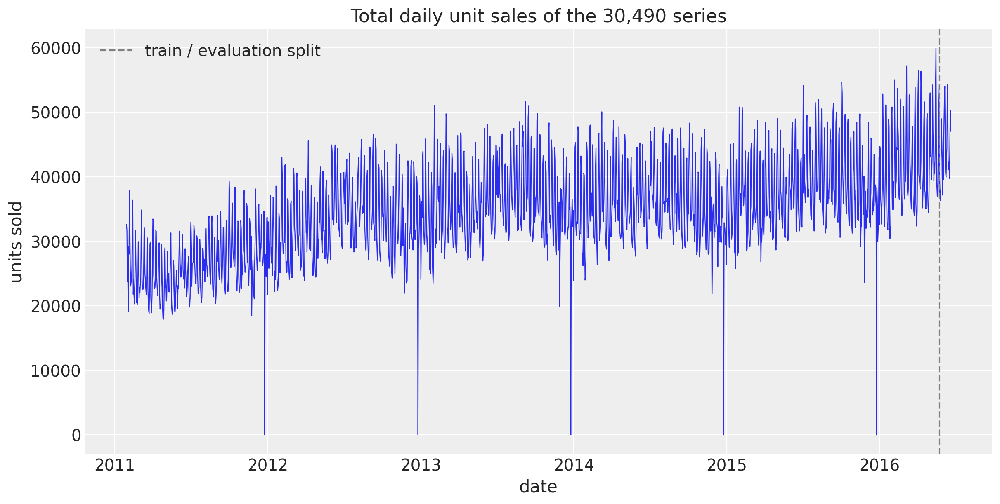

In [6]:
dates = calendar_df["date"].to_numpy()[:N_DAYS]
date_num = np.asarray(mdates.date2num(dates.astype("datetime64[s]").astype(object)))
split_date = date_num[N_DAYS_TRAIN]
y_total = sales_agg[:, 0]

fig, ax = plt.subplots()
ax.plot(date_num, y_total, color="C0", lw=0.8)
ax.axvline(split_date, color="gray", ls="--", label="train / evaluation split")
ax.xaxis_date()
ax.legend(loc="upper left")
ax.set(title="Total daily unit sales of the 30,490 series", xlabel="date", ylabel="units sold");

The 70 store-by-department series (level 9) are the data of model 3. The seven departments of the first store show the range of scales and the weekly pattern that the models have to capture.

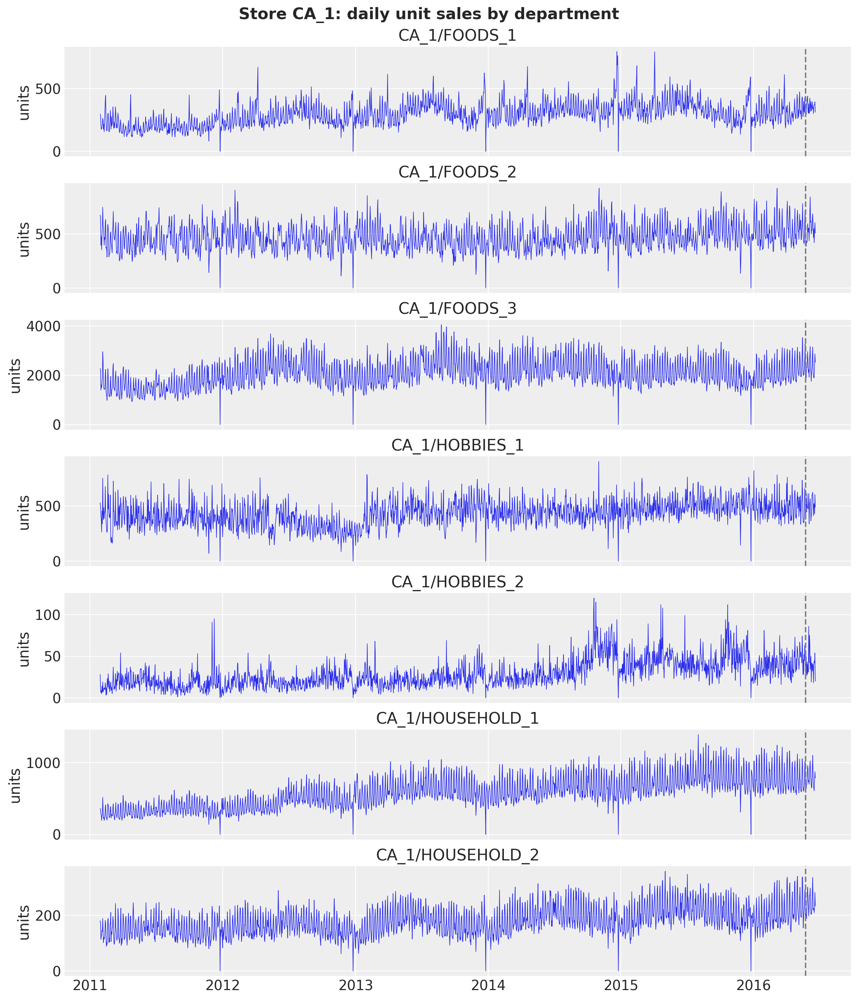

In [7]:
level9_labels = [label.removeprefix("Level9/") for label in agg_labels[level_slices["Level9"]]]
y_level9 = sales_agg[:, level_slices["Level9"]]
ca1_columns = [k for k, label in enumerate(level9_labels) if label.startswith("CA_1/")]

fig, axes = plt.subplots(
    nrows=len(ca1_columns), ncols=1, figsize=(12, 14), sharex=True, layout="constrained"
)
for ax, k in zip(axes, ca1_columns, strict=True):
    ax.plot(date_num, y_level9[:, k], color="C0", lw=0.6)
    ax.axvline(split_date, color="gray", ls="--")
    ax.set(ylabel="units", title=level9_labels[k])
axes[-1].xaxis_date()
fig.suptitle("Store CA_1: daily unit sales by department", fontsize=16, fontweight="bold");

At the bottom level most series are intermittent. Among the days with a listed price, the share of days with zero sales runs from about a half (`FOODS_3`, `HOUSEHOLD_1`) to 85% (`HOBBIES_2`); the food departments are the least intermittent and sell the most units per day.

In [8]:
zero_days = pl.DataFrame(
    {
        "dept_id": hierarchy_df["dept_id"],
        "zero_share": ((sales[:N_DAYS_TRAIN] == 0) * saled[:N_DAYS_TRAIN]).sum(0)
        / np.maximum(saled[:N_DAYS_TRAIN].sum(0), 1.0),
        "mean_daily_sales": sales[:N_DAYS_TRAIN].mean(0),
    }
)
(
    zero_days.group_by("dept_id")
    .agg(
        series=pl.len(),
        zero_share=pl.col("zero_share").mean(),
        mean_daily_sales=pl.col("mean_daily_sales").mean(),
    )
    .sort("dept_id")
    .with_columns(pl.col(pl.Float32, pl.Float64).round(3))
)

dept_id,series,zero_share,mean_daily_sales
"""FOODS_1""",2160,0.568,1.238
"""FOODS_2""",3980,0.568,1.009
"""FOODS_3""",8230,0.487,2.062
"""HOBBIES_1""",4160,0.677,0.706
"""HOBBIES_2""",1490,0.848,0.187
"""HOUSEHOLD_1""",5320,0.521,1.135
"""HOUSEHOLD_2""",5150,0.765,0.304


We keep seven items for the item-level plots: the best seller of each department in store CA_1 over the last training year.

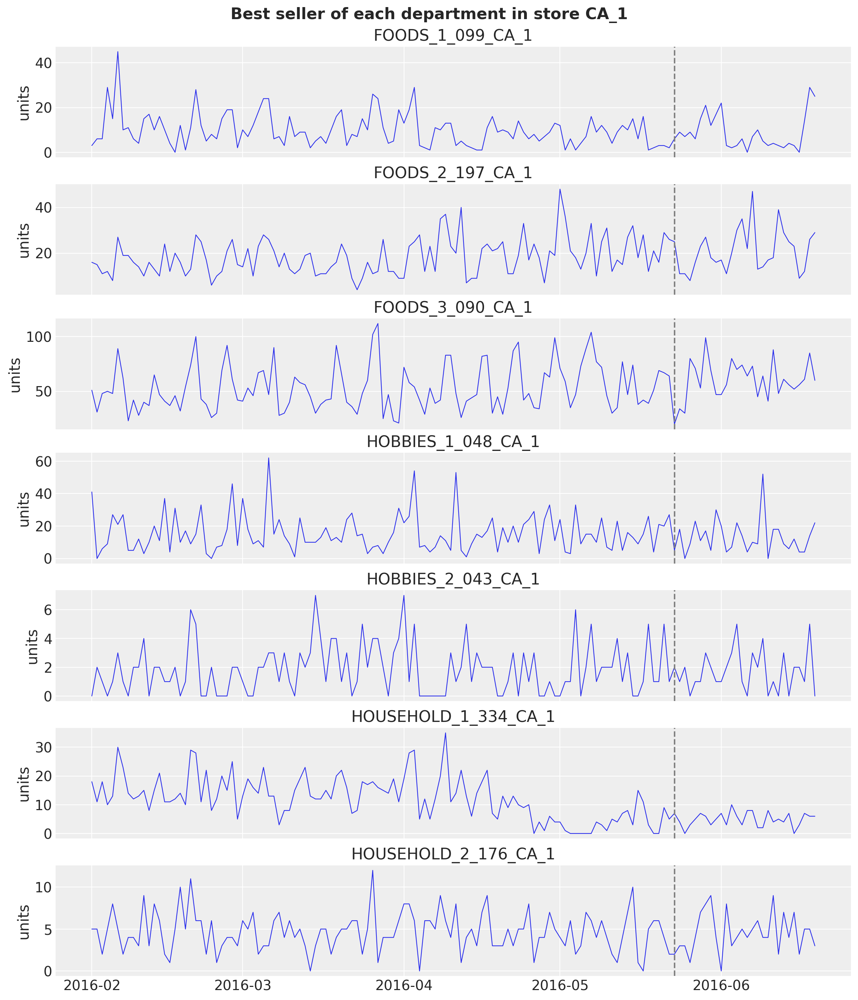

In [9]:
last_year_sales = sales[N_DAYS_TRAIN - 365 : N_DAYS_TRAIN].sum(0)
focus_df = (
    hierarchy_df.with_row_index("n")
    .with_columns(last_year=pl.Series(last_year_sales))
    .filter(pl.col("store_id").eq(pl.lit("CA_1")))
    .sort("last_year", descending=True)
    .group_by("dept_id", maintain_order=True)
    .head(1)
    .sort("dept_id")
)
focus_index = focus_df["n"].to_numpy()
focus_labels = focus_df["id"].to_list()
plot_start = N_DAYS_TRAIN - 16 * 7

fig, axes = plt.subplots(
    nrows=len(focus_labels), ncols=1, figsize=(12, 14), sharex=True, layout="constrained"
)
for ax, n, label in zip(axes, focus_index, focus_labels, strict=True):
    ax.plot(date_num[plot_start:], sales[plot_start:, n], color="C0", lw=0.8)
    ax.axvline(split_date, color="gray", ls="--")
    ax.set(ylabel="units", title=label)
axes[-1].xaxis_date()
fig.suptitle("Best seller of each department in store CA_1", fontsize=16, fontweight="bold");

## Scoring at every level

The kit's `m5_backtest` scores a forecast of the 42,840 series with the structure of the competition metrics. For a series $s$ at a level $\ell$ with $n_\ell$ series, let $c_s$ be the mean CRPS of its 28-day forecast, $w_s$ its share of the dollar sales of the level over the 28 days before the forecast origin (so the weights of a level sum to one), and $\sigma_s$ its scale, the mean absolute lag-one difference of the training series after its first nonzero value (the scale of the competition's pinball loss):

$$
\text{WS-CRPS} = \frac{1}{12} \sum_{\ell=1}^{12} \sum_{s \in \ell} w_s \frac{c_s}{\sigma_s}.
$$

The dollar sales are the sales times the shelf price; the scale clamps the sum of the absolute differences at one (as the kit does) so a series that never moves does not get an infinite score. The weights depend on the forecast origin, so they are built per window. We check them against the official weights of the evaluation window, which validates the aggregation matrix and the price join in one go.

In [10]:
def m5_weights(t1: int) -> np.ndarray:
    """Dollar-sales share of every aggregate over the 28 days before ``t1``, normalized per level."""
    dollars = (sales[t1 - 28 : t1] * price_filled[t1 - 28 : t1]).sum(0) @ agg_matrix
    weights = np.empty_like(dollars)
    for level_slice in level_slices.values():
        weights[level_slice] = dollars[level_slice] / dollars[level_slice].sum()
    return weights


def m5_scales(y: np.ndarray) -> np.ndarray:
    """Mean absolute lag-1 difference of every column of ``y`` over its active period.

    The active period starts at the first nonzero value; the jump from zero on that day is
    excluded, the sum of absolute differences is clamped at one and divided by the number of
    active days minus one (the kit's ``get_metric_scale("pl", ...)``).
    """
    duration, n_columns = y.shape
    active = np.maximum((np.cumsum(y, axis=0) != 0).sum(0), 2)
    start_value = y[duration - active, np.arange(n_columns)]
    lag1_norm = np.abs(np.diff(y, axis=0, prepend=0.0)).sum(0) - np.abs(start_value)
    return np.maximum(lag1_norm, 1.0) / (active - 1)


weights_holdout = m5_weights(N_DAYS_TRAIN)
scales_holdout = m5_scales(sales_agg[:N_DAYS_TRAIN])
official_weights = m5.weights.with_columns(
    label=pl.concat_str(
        [pl.col("Level_id"), pl.col("Agg_Level_1"), pl.col("Agg_Level_2")], separator="/"
    )
)
weights_check = official_weights.join(
    pl.DataFrame({"label": agg_labels, "weight_ours": weights_holdout}), on="label", how="inner"
)
max_weight_gap = weights_check.select(
    (pl.col("weight") - pl.col("weight_ours")).abs().max()
).item()
print(f"{weights_check.height} aggregates matched, largest weight gap {max_weight_gap:.1e}")
assert weights_check.height == len(agg_labels)
assert max_weight_gap < 1e-4

42840 aggregates matched, largest weight gap 2.0e-06


The scoring functions plug into `backtest()`: a `transform` sums the bottom-level draws and the truth to the 42,840 aggregates, and `per_window_metrics` returns one weighted scaled CRPS per level for the window's origin, so every series is sorted once. The headline WS-CRPS is the mean of the 12 level scores.

In [11]:
def aggregate_transform(
    pred: np.ndarray | Array, truth: np.ndarray | Array
) -> tuple[np.ndarray, np.ndarray]:
    """Sum bottom-level draws and truth to the 42,840 aggregates of the 12 M5 levels."""
    n = pred.shape[-1]
    pred_levels = np.asarray(pred, dtype=np.float32).reshape(-1, n) @ agg_matrix
    truth_levels = np.asarray(truth, dtype=np.float32) @ agg_matrix
    return pred_levels.reshape(*pred.shape[:-1], -1), truth_levels


def ws_crps_level(
    pred: Array, truth: Array, *, level_slice: slice, weights: np.ndarray, scales: np.ndarray
) -> Array:
    """Weighted scaled CRPS of one level: weight times mean CRPS over the horizon, over scale."""
    crps = crps_empirical(pred[..., level_slice], truth[..., level_slice]).mean(axis=0)
    return jnp.sum(jnp.asarray(weights) * crps / jnp.asarray(scales))


def m5_metrics(t0: int, t1: int, t2: int) -> dict:
    """Build the 12 weighted scaled CRPS metrics of a window whose training data ends at ``t1``."""
    weights = m5_weights(t1)
    scales = m5_scales(sales_agg[:t1])
    return {
        f"ws_crps_{level}": partial(
            ws_crps_level,
            level_slice=level_slice,
            weights=weights[level_slice],
            scales=scales[level_slice],
        )
        for level, level_slice in level_slices.items()
    }


def ws_crps_table(scores: dict[str, dict[str, float]]) -> pl.DataFrame:
    """Table of the per-level WS-CRPS of several models, with the mean over levels as last row."""
    table = pl.DataFrame(
        {"level": list(LEVELS)}
        | {
            model: [values[f"ws_crps_{level}"] for level in LEVELS]
            for model, values in scores.items()
        }
    )
    mean_row = table.select(pl.lit("mean").alias("level"), pl.exclude("level").mean())
    return pl.concat([table, mean_row]).with_columns(pl.exclude("level").round(3))

The official pinball loss of the uncertainty competition (WSPL) has the same weights and scales, with the mean pinball loss over the nine competition quantiles in place of the CRPS. We compute it on the evaluation window to compare with the published leaderboard.

In [12]:
M5_QUANTILES = np.array(
    [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995], dtype=np.float32
)


def ws_pinball(
    pred_levels: np.ndarray, truth_levels: np.ndarray, weights: np.ndarray, scales: np.ndarray
) -> float:
    """M5 WSPL: pinball loss at the nine competition quantiles, weighted, scaled, mean over levels."""
    quantiles = np.quantile(pred_levels, M5_QUANTILES, axis=0)
    error = quantiles - truth_levels[None]
    u = M5_QUANTILES[:, None, None]
    per_series = (np.where(error <= 0, -u, 1 - u) * error).mean(axis=(0, 1))
    level_scores = [
        np.sum(weights[level_slice] * per_series[level_slice] / scales[level_slice])
        for level_slice in level_slices.values()
    ]
    return float(np.mean(level_scores))

### Reconciliation

Models 1 and 3 forecast an aggregate. The kit's submission splits such a forecast to the items in proportion to their sales over the last 28 training days and draws Poisson noise at the bottom, so that the item forecasts are integer and their spread at the bottom is not just a scaled copy of the aggregate's. The Poisson draws use NumPy: `jax.random.poisson` on the CPU is about 40 times slower for an array of this size.

In [13]:
def last_28_day_shares(train_sales: np.ndarray, group_index: np.ndarray) -> np.ndarray:
    """Share of every series in the sales of its group over the last 28 training days."""
    totals = np.asarray(train_sales[-28:], dtype=np.float64).sum(0)
    n_groups = int(group_index.max()) + 1
    group_totals = np.bincount(group_index, weights=totals, minlength=n_groups)
    group_sizes = np.bincount(group_index, minlength=n_groups)
    shares = np.where(
        group_totals[group_index] > 0,
        totals / group_totals[group_index],
        1.0 / group_sizes[group_index],
    )
    return shares.astype(np.float32)


def disaggregate(
    seed: int,
    group_draws: np.ndarray,
    shares: np.ndarray,
    group_index: np.ndarray,
    chunk: int = 50,
    rate_cap: float = 1e9,
) -> np.ndarray:
    """Poisson draws at the bottom level with rate ``group draw x share`` (kit submission logic)."""
    rng = np.random.default_rng(seed)
    out = np.empty((*group_draws.shape[:-1], shares.shape[0]), dtype=np.float32)
    for start in range(0, group_draws.shape[0], chunk):
        rate = np.asarray(group_draws[start : start + chunk], dtype=np.float32)[..., group_index]
        rate = np.clip(np.nan_to_num(rate * shares, nan=0.0, posinf=rate_cap), 0.0, rate_cap)
        out[start : start + chunk] = rng.poisson(rate)
    return out


total_index = np.zeros(n_series, dtype=np.int64)
level9_index = hierarchy_df["Level9"].to_numpy()
level3_index = hierarchy_df["Level3"].to_numpy()
store_ids = [
    label.removeprefix("Level3/").removesuffix("/X")
    for label in agg_labels[level_slices["Level3"]]
]
dept_ids = [
    label.removeprefix("Level5/").removesuffix("/X")
    for label in agg_labels[level_slices["Level5"]]
]

## Shared fitting and plotting helpers

All three models use the kit's optimizer: Adam with the gradients clipped at a global norm of 10 and a learning rate of 0.1 that decays exponentially to 0.01 over the run (`learning_rate_decay=0.1` in Pyro's `Forecaster`). The step counts are the kit's defaults, 1,001 for models 1 and 2 and 2,001 for model 3.

In [14]:
def kit_optimizer(num_steps: int) -> numpyro.optim._NumPyroOptim:
    """Build the kit's ClippedAdam: clipped gradients, learning rate decaying tenfold over the run."""
    schedule = optax.exponential_decay(0.1, transition_steps=num_steps, decay_rate=0.1)
    return optax_to_numpyro(optax.chain(optax.clip_by_global_norm(10.0), optax.adam(schedule)))


def fit_svi(
    rng_key: Array,
    model: ForecastModel,
    guide: AutoNormal,
    num_steps: int,
    covariates: Array,
    data: Array,
) -> tuple[SVIRunResult, float]:
    """Run SVI with the kit's optimizer; return the result and the wall time in seconds."""
    svi = SVI(model, guide, kit_optimizer(num_steps), Trace_ELBO())
    start = perf_counter()
    result = svi.run(rng_key, num_steps, covariates, data, progress_bar=False)
    jax.block_until_ready(result.losses)
    return result, perf_counter() - start


NUM_STEPS = {"top-down": 1_001, "bottom-up": 1_001, "middle-out": 2_001}
HDI_PROBS = (0.94, 0.5)
HDI_ALPHAS = (0.3, 0.6)
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def hdi_label(prob: float) -> str:
    r"""Legend label of an HDI band, for example ``$94\%$ HDI``."""
    return rf"${prob:.0%}$ HDI".replace("%", r"\%")


def add_date_variable(tree: xr.DataTree, date_num: np.ndarray) -> xr.DataTree:
    """Add a matplotlib date number ``date`` variable to the constant data groups of a tree."""
    for group in ("constant_data", "predictions_constant_data"):
        if group in tree.children:
            dataset = tree[group].dataset
            tree[group] = dataset.assign(date=("time", date_num[dataset["time"].values]))
    return tree


def plot_loss(losses: Array, title: str) -> None:
    """Plot an ELBO loss curve on a symmetric log scale."""
    _, ax = plt.subplots(figsize=(10, 4))
    ax.plot(np.asarray(losses), color="C0")
    ax.set_yscale("symlog")
    ax.set(title=title, xlabel="SVI step", ylabel="loss")


def plot_series_panel(
    train_draws: np.ndarray | Array | None,
    test_draws: np.ndarray | Array,
    truth: np.ndarray,
    labels: list[str],
    x_train: np.ndarray,
    x_test: np.ndarray,
    *,
    ylabel: str,
    suptitle: str,
    col_wrap: int = 2,
    figsize: tuple[float, float] = (15.0, 10.0),
    group: str = "posterior_predictive",
) -> None:
    """Facet the predictive bands of a few series over a window, with the observed series.

    ``train_draws`` (in-sample, blue) may be ``None``; ``test_draws`` (forecast, orange) are
    always drawn. ``truth`` covers ``x_train`` followed by ``x_test``.
    """
    visuals = {
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    }
    first_draws, first_x = (test_draws, x_test) if train_draws is None else (train_draws, x_train)
    pc = az.plot_lm(
        predictions_to_datatree(np.asarray(first_draws), first_x, labels, group=group),
        y="obs",
        x="t",
        plot_dim="time",
        group=group,
        ci_kind="hdi",
        ci_prob=HDI_PROBS,
        smooth=False,
        col_wrap=col_wrap,
        visuals=visuals if train_draws is not None else {**visuals, "ci_band": {"color": "C1"}},
        aes={"alpha": ["prob"]},
        alpha=HDI_ALPHAS,
        figure_kwargs={"figsize": figsize},
    )
    if train_draws is not None:
        az.plot_lm(
            predictions_to_datatree(np.asarray(test_draws), x_test, labels, group=group),
            y="obs",
            x="t",
            plot_dim="time",
            group=group,
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=HDI_PROBS,
            smooth=False,
            visuals={**visuals, "ci_band": {"color": "C1"}},
        )
    x_all = np.concatenate([x_train, x_test]) if train_draws is not None else x_test
    truth_da = xr.DataArray(
        np.asarray(truth)[-len(x_all) :],
        dims=["time", "series"],
        coords={"time": x_all, "series": labels},
    ).rename("t")
    x_da = xr.DataArray(x_all, dims=["time"], coords={"time": x_all})
    pc.map(
        az.visuals.line_xy,
        "truth",
        data=truth_da,
        x=x_da,
        ignore_aes=pc.aes_set,
        color="black",
        lw=1,
    )
    for label in labels:
        ax = pc.get_target("t", {"series": label})
        ax.set_title(label, fontsize=11)
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax0 = pc.get_target("t", {"series": labels[0]})
    handles = []
    for prob in HDI_PROBS:
        band = pc.viz["ci_band"]["t"].sel(series=labels[0], prob=prob).item()
        band.set_label(hdi_label(prob))
        handles.append(band)
    truth_line = pc.viz["truth"]["t"].sel(series=labels[0]).item()
    truth_line.set_label("observed")
    ax0.legend(handles=[*handles, truth_line], loc="upper left", fontsize=9)
    fig = pc.viz["figure"].item()
    fig.supylabel(ylabel)
    fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.02)

## Model 1: top-down

### Model specification

Model 1 works on the log of the total daily sales, $y_t = \log \sum_{i} \text{sales}_{i,t}$ over the 30,490 series. With $\tau_t$ the time in years, $d(t)$ the weekday and $\mathbf{x}_t$ the 31 day-of-month dummies of day $t$,

$$
\begin{align*}
\mu_t &= \beta_0 + \beta_{\text{trend}}\, \tau_t + s_{d(t)} + \mathbf{w}^\top \mathbf{x}_t, \\
y_t &\sim \text{StudentT}(\nu, \mu_t, \sigma),
\end{align*}
$$

with the kit's priors $\beta_0 \sim \text{Normal}(0, 10)$, $\beta_{\text{trend}} \sim \text{LogNormal}(-2, 1)$ (sales grow, so the slope is positive), $s_d \sim \text{Normal}(0, 5)$, $w_j \sim \text{Normal}(0, 1)$, $\nu \sim \text{Uniform}(1, 10)$ and $\sigma \sim \text{LogNormal}(-2, 1)$. The heavy tails absorb the Christmas days. The intercept, the seven weekday effects and the 31 day-of-month dummies are collinear (any constant can move between them), as in the kit; the mean-field guide picks one split and the forest plots below should be read for their relative pattern.

The model has no latent time process, so `predict()` is the only building block it needs. The forecast covariates are just the calendar of the next 28 days.

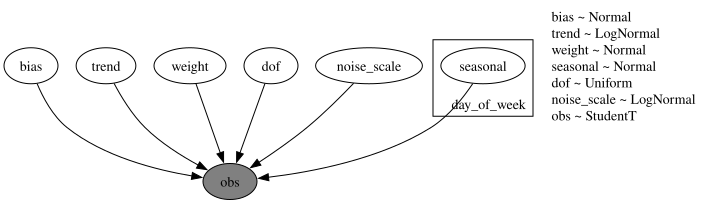

In [15]:
covariates_top = jnp.asarray(
    np.column_stack(
        [
            calendar_df["years"].to_numpy()[:N_DAYS],
            calendar_df["dow"].to_numpy()[:N_DAYS],
            calendar_df.select(pl.col("^dom_.*$")).to_numpy()[:N_DAYS],
        ]
    ).astype(np.float32)
)
covariates_top_train = covariates_top[:N_DAYS_TRAIN]
y_top = jnp.asarray(np.log(y_total)[:, None], dtype=jnp.float32)
y_top_train = y_top[:N_DAYS_TRAIN]


def top_down_model(covariates: Array, data: Array | None = None) -> None:
    """Kit model 1: trend, weekday and day-of-month effects on the log of the total sales."""
    h = Horizon.from_data(covariates, data)
    time = covariates[:, 0]
    dow = covariates[:, 1].astype(jnp.int32)
    feature = covariates[:, 2:]
    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    trend = numpyro.sample("trend", dist.LogNormal(-2.0, 1.0))
    weight = numpyro.sample(
        "weight", dist.Normal(0.0, 1.0).expand([feature.shape[-1]]).to_event(1)
    )
    with numpyro.plate("day_of_week", 7):
        seasonal = numpyro.sample("seasonal", dist.Normal(0.0, 5.0))
    prediction = bias + trend * time + seasonal[dow] + feature @ weight
    dof = numpyro.sample("dof", dist.Uniform(1.0, 10.0))
    noise_scale = numpyro.sample("noise_scale", dist.LogNormal(-2.0, 1.0))
    predict(h, dist.StudentT(dof, 0.0, noise_scale), prediction[:, None])


numpyro.render_model(
    top_down_model, model_args=(covariates_top_train, y_top_train), render_distributions=True
)

### Prior predictive check

The kit's priors are wide on the log scale: an intercept with a standard deviation of 10, weekday effects with a standard deviation of 5 and a unit-variance weight on each of the 31 dummies. The $94\%$ prior band spans about $-20$ to $20$ and the observed log total of about 10.4 sits at the edge of the $50\%$ band: weakly informative priors that the 1,941 observations will dominate. The plot shows the last twenty weeks of the training data against the prior bands.

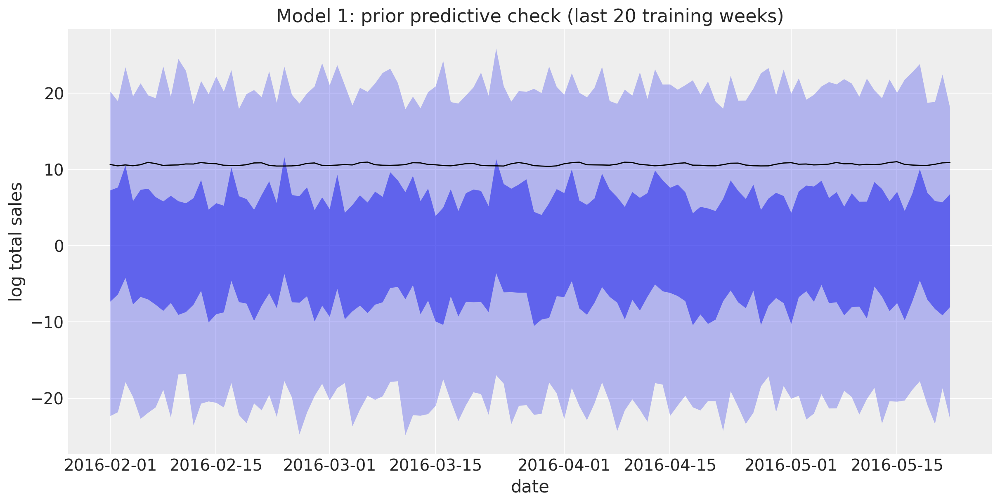

In [16]:
rng_key, key_prior = random.split(rng_key)
prior_obs_top = Predictive(top_down_model, num_samples=500, return_sites=["obs"])(
    key_prior, covariates_top_train
)["obs"][..., 0]

prior_tree_top = predictions_to_datatree(
    np.asarray(prior_obs_top[:, plot_start:, None]),
    date_num[plot_start:N_DAYS_TRAIN],
    ["log total sales"],
    group="prior_predictive",
    observed=np.asarray(y_top_train[plot_start:]),
)
pc = az.plot_lm(
    prior_tree_top,
    y="obs",
    x="t",
    plot_dim="time",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=HDI_PROBS,
    smooth=False,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    },
    aes={"alpha": ["prob"]},
    alpha=HDI_ALPHAS,
    figure_kwargs={"figsize": (12, 6)},
)
ax = pc.viz["figure"].item().axes[0]
ax.plot(
    date_num[plot_start:N_DAYS_TRAIN], np.asarray(y_top_train[plot_start:, 0]), color="black", lw=1
)
ax.xaxis_date()
ax.set(
    title="Model 1: prior predictive check (last 20 training weeks)",
    xlabel="date",
    ylabel="log total sales",
);

### Fit

The final fit uses the full training period. We time it with `jax.block_until_ready` so the JIT compilation is included, as it is in every backtest window.

model 1: 1001 steps in 4.1 s, final loss -1402.0


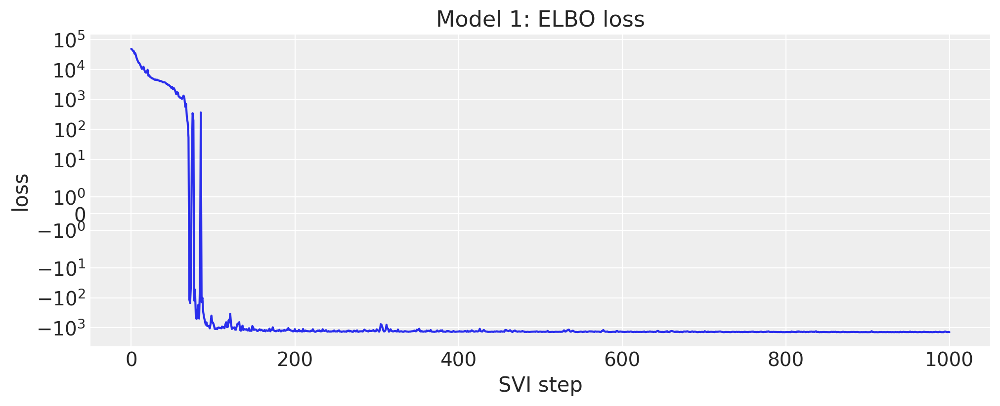

In [17]:
rng_key, key_fit = random.split(rng_key)
guide_top = AutoNormal(top_down_model)
svi_top, time_top = fit_svi(
    key_fit, top_down_model, guide_top, NUM_STEPS["top-down"], covariates_top_train, y_top_train
)
print(
    f"model 1: {NUM_STEPS['top-down']} steps in {time_top:.1f} s, final loss {float(svi_top.losses[-1]):.1f}"
)
plot_loss(svi_top.losses, "Model 1: ELBO loss")

### Posterior

`to_datatree` exports the posterior, the in-sample posterior predictive and the forecast to ArviZ in one call. The trend is about 0.08 per year on the log scale (8% a year), the StudentT degrees of freedom are around 4, and the noise scale on the log scale is 0.08.

In [18]:
rng_key, key_post, key_tree = random.split(rng_key, 3)
posterior_top = draw_posterior(key_post, guide_top, svi_top.params, 500)
tree_top = to_datatree(
    key_tree,
    top_down_model,
    posterior_top,
    y_top_train,
    covariates_top,
    coords={"day_of_week": DOW_LABELS, "day_of_month": list(range(1, 32))},
    posterior_dims={"seasonal": ["day_of_week"], "weight": ["day_of_month"]},
)
tree_top = add_date_variable(tree_top, date_num)
for group in ("posterior_predictive", "observed_data", "predictions"):
    tree_top[group] = tree_top[group].dataset.isel(obs_dim=0)
az.summary(tree_top, var_names=["bias", "trend", "dof", "noise_scale"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
bias,4.8395,0.0035,4.8,4.8,411,452,nan,0.00017,0.00011
trend,0.0795,0.00117,0.078,0.081,491,523,nan,5.3e-05,3.2e-05
dof,3.9,0.23,3.5,4.3,485,527,nan,0.01,0.0083
noise_scale,0.0781,0.0017,0.076,0.081,510,518,nan,7.5e-05,5.1e-05


The weekday effects show the weekend peak (Saturday and Sunday about 0.33 above the midweek days on the log scale, about 40% more sales) and the day-of-month effects the pay-day pattern: the first days of the month sell more than the last ones.

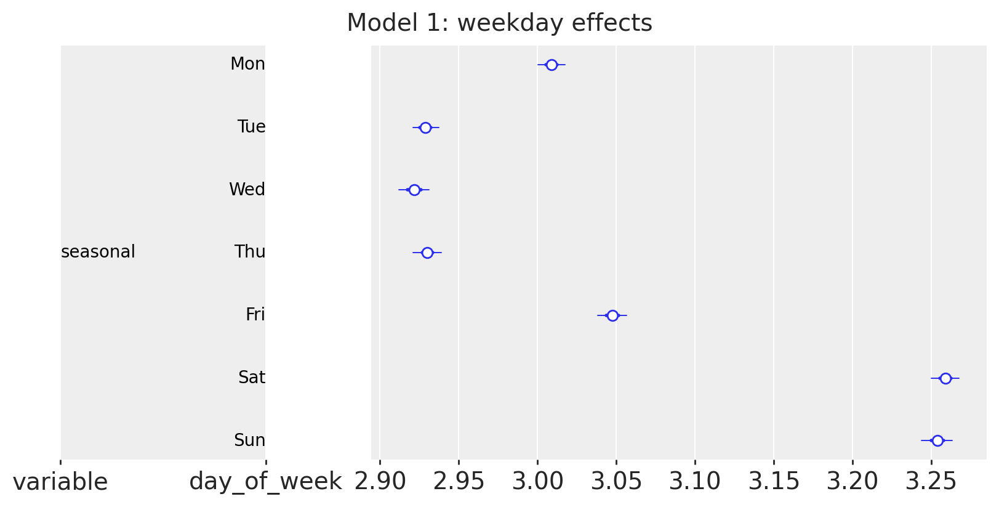

In [19]:
pc = az.plot_forest(
    tree_top, var_names=["seasonal"], combined=True, figure_kwargs={"figsize": (8, 4)}
)
pc.viz["figure"].item().suptitle("Model 1: weekday effects", fontsize=14);

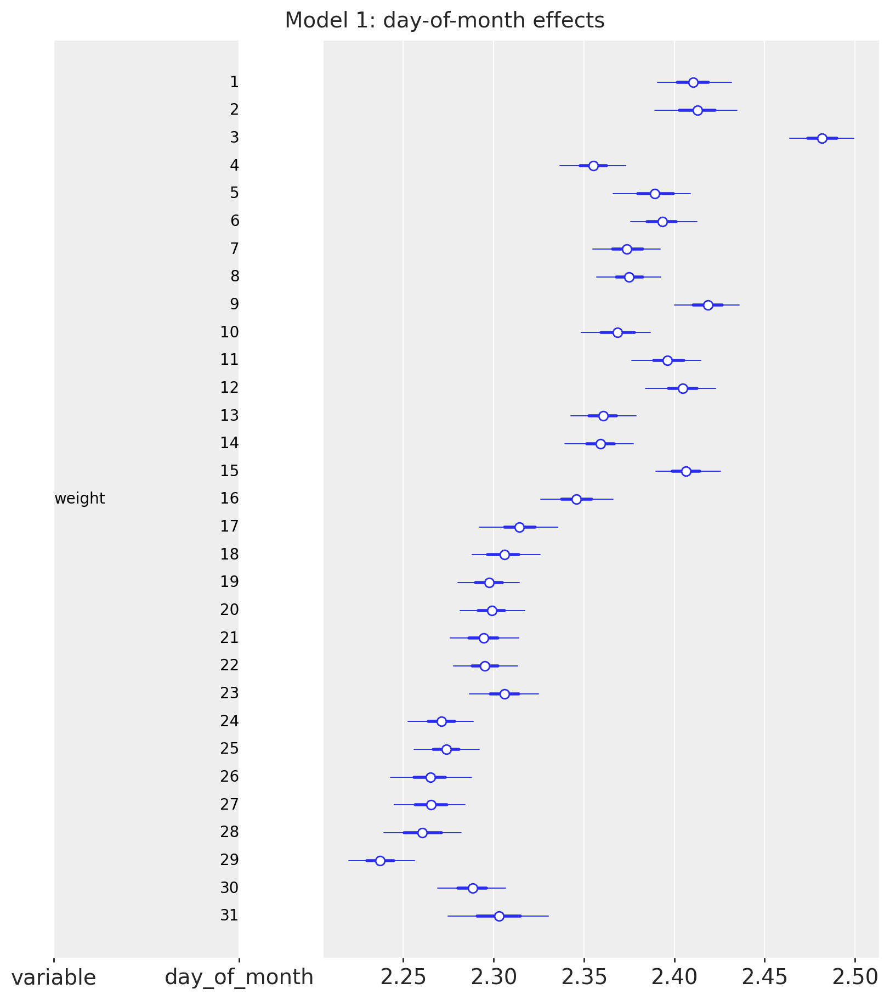

In [20]:
pc = az.plot_forest(
    tree_top, var_names=["weight"], combined=True, figure_kwargs={"figsize": (8, 9)}
)
pc.viz["figure"].item().suptitle("Model 1: day-of-month effects", fontsize=14);

### Forecast

The in-sample posterior predictive (blue) and the 28-day forecast (orange) on the log scale, over the last twenty training weeks and the evaluation window.

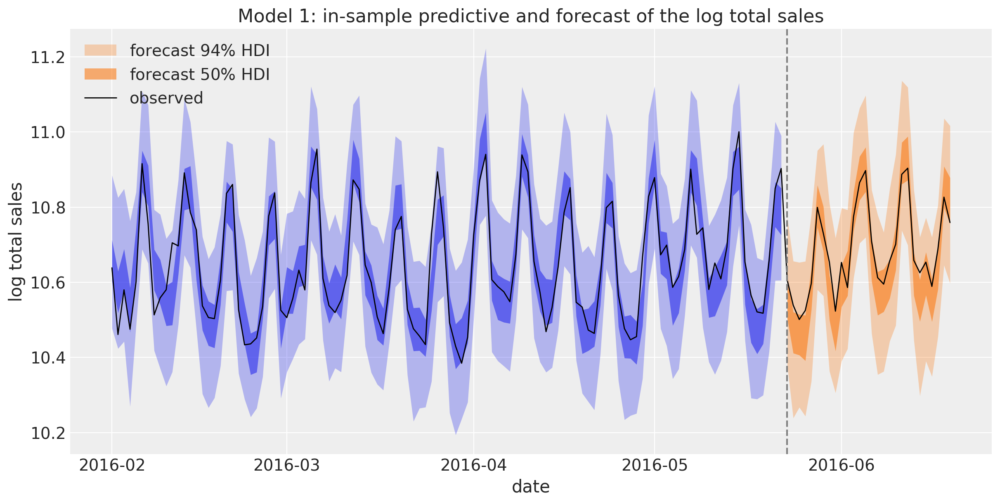

In [21]:
tree_top_zoom = tree_top.copy()
for group in ("posterior_predictive", "observed_data", "constant_data"):
    tree_top_zoom[group] = tree_top[group].dataset.isel(time=slice(plot_start, None))
pc = az.plot_lm(
    tree_top_zoom,
    y="obs",
    x="date",
    group="posterior_predictive",
    ci_kind="hdi",
    ci_prob=HDI_PROBS,
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    aes={"alpha": ["prob"]},
    alpha=HDI_ALPHAS,
    figure_kwargs={"figsize": (12, 6)},
)
az.plot_lm(
    tree_top_zoom,
    y="obs",
    x="date",
    group="predictions",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=HDI_PROBS,
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
ax = pc.viz["figure"].item().axes[0]
(observed_line,) = ax.plot(
    date_num[plot_start:], np.log(y_total[plot_start:]), color="black", lw=1, label="observed"
)
ax.axvline(split_date, color="gray", ls="--")
ax.xaxis_date()
band_handles = []
for prob in HDI_PROBS:
    band = pc.viz["ci_band"]["date"].sel(prob=prob).item()
    band.set_label(f"forecast {hdi_label(prob)}")
    band_handles.append(band)
ax.legend(handles=[*band_handles, observed_line], loc="upper left")
ax.set(
    title="Model 1: in-sample predictive and forecast of the log total sales",
    ylabel="log total sales",
);

### Top-down split and scores

The forecast draws go back to units with `exp`, are split to the items with their last-28-day shares and get Poisson noise. The bottom-level draws are then summed to every level and scored. The split does not know anything about the items, so the item levels (10 to 12) measure the share heuristic, not the model.

In [22]:
rng_key, key_fc = random.split(rng_key)
fc_top = np.exp(
    np.asarray(forecast(key_fc, top_down_model, posterior_top, y_top_train, covariates_top))
)
shares_top = last_28_day_shares(sales[:N_DAYS_TRAIN], total_index)
bottom_top = disaggregate(N_DAYS_TRAIN, fc_top, shares_top, total_index)
truth_holdout = sales[N_DAYS_TRAIN:N_DAYS]
holdout_metrics = m5_metrics(0, N_DAYS_TRAIN, N_DAYS)

pred_levels, truth_levels = aggregate_transform(bottom_top, truth_holdout)
scores_holdout = {
    "top-down": evaluate_forecast(pred_levels, truth_levels, metrics=holdout_metrics)
}
wspl_holdout = {"top-down": ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)}
level1_draws = {"top-down": pred_levels[..., level_slices["Level1"]]}
level3_draws = {"top-down": pred_levels[..., level_slices["Level3"]]}
del bottom_top, pred_levels
mean_ws_crps = np.mean(list(scores_holdout["top-down"].values()))
print(
    f"model 1 evaluation window: WS-CRPS {mean_ws_crps:.3f}, WSPL {wspl_holdout['top-down']:.3f}"
)

model 1 evaluation window: WS-CRPS 0.569, WSPL 0.197


The split forecast at the store level (level 3) shows what top-down means: every store gets the same shape, scaled by its share.

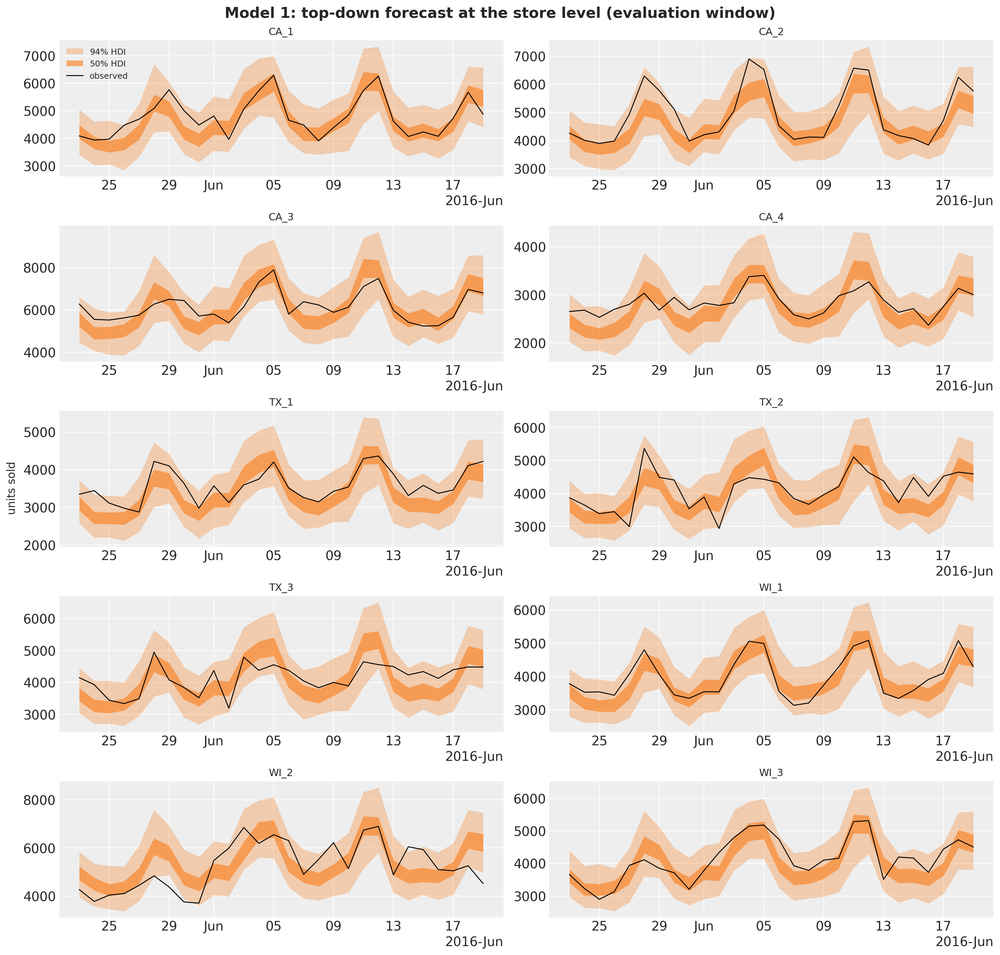

In [23]:
plot_series_panel(
    None,
    level3_draws["top-down"],
    sales_agg[N_DAYS_TRAIN:N_DAYS, level_slices["Level3"]],
    store_ids,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Model 1: top-down forecast at the store level (evaluation window)",
    figsize=(15.0, 14.0),
)

## Model 2: bottom-up

### Model specification

Model 2 is a regression for every item in every store. For item $i$ in department $d(i)$ of store $r(i)$, day $t$, the covariates are the log of three lagged moving averages of its own sales ($\text{MA}_{k,i,t}$ over the 28, 56 and 84 days ending 28 days before $t$, so they are known over the whole horizon), the SNAP flag of the store's state, and the weekday. Two linear predictors, one for the mean and one for the scale of a Gamma distribution, share their weights across the items of a department in a store:

$$
\begin{align*}
\eta^{(h)}_{i,t} &= \sum_{k=1}^{3} w^{(h)}_{r(i), k, d(i)} \log \text{MA}_{k,i,t} + b^{(h)}_{r(i), d(i)}\, \text{snap}_{r(i), t} + s^{(h)}_{r(i), d(t), d(i)}, \qquad h \in \{\text{mean}, \text{scale}\}, \\
m_{i,t} &= \text{bexp}(\eta^{(\text{mean})}_{i,t})\, \text{saled}_{i,t} + 10^{-3}, \qquad
v_{i,t} = \text{bexp}(\eta^{(\text{scale})}_{i,t})\, \text{saled}_{i,t} + 10^{-3}, \\
y_{i,t} &\sim \text{Gamma}\left(\frac{m_{i,t}}{v_{i,t}}, \frac{1}{v_{i,t}}\right),
\end{align*}
$$

with all weights $\sim \text{Normal}(0, 1)$, $\text{bexp}(x) = 10^3\, \text{sigmoid}(x - \log 10^3)$ the kit's bounded exponential (it keeps the early training steps finite), and $\text{saled}_{i,t}$ the price-listed flag that forces the mean to the floor when the item is not on the shelf. The Gamma with mean $m$ and variance $m v$ is a continuous stand-in for a count likelihood: the kit clamps the sales at $10^{-3}$ to make the zeros admissible. There are no item-level parameters: an item is described by its department's weights and its own moving averages.

Training subsamples the series plate. The guide's `create_plates` opens the `series` plate with `subsample_size=600`; under `replay` the model's plate receives the same indices, `numpyro.subsample` picks the matching columns of the data and the covariates, and the observed log density is scaled by $30{,}490 / 600$. `Horizon.from_data` is called on the subsampled arrays, so `predict()` observes the minibatch. `forecast()` and `Predictive` run without the guide and see the full plate. The Gamma distribution is not a location family, so it enters `predict()` through a link that maps the mean to the distribution, after registering it as elementwise for the prefix conditioning.

In [24]:
register_elementwise(dist.Gamma)
T0 = 121  # kit: 37 + 28 * 3, the first day with the three moving averages defined
MA_WINDOWS = (28, 56, 84)
MA_LAG = 28
N_STORES, N_DEPTS = len(store_ids), len(dept_ids)
SUBSAMPLE_SIZE = 600
TAIL = 7  # days of history passed to forecast(); the model needs none, a week keeps the plots readable


def lagged_log_moving_average(y: np.ndarray, window: int, lag: int) -> np.ndarray:
    """Log of the mean of ``y`` over the ``window`` days ending ``lag`` days before each day.

    Days without a full window are set to ``log(1e-3)``, the kit's clamp floor.
    """
    padded = np.concatenate([np.zeros((1, y.shape[1])), np.cumsum(y, axis=0, dtype=np.float64)])
    t = np.arange(y.shape[0])
    stop = np.clip(t - lag + 1, 0, None)
    start = np.clip(stop - window, 0, None)
    mean = (padded[stop] - padded[start]) / window
    mean[t - lag + 1 - window < 0] = 0.0
    return np.log(np.maximum(mean, 1e-3)).astype(np.float32)


state_index = hierarchy_df["Level2"].to_numpy()
snap_by_state = calendar_df.select("snap_CA", "snap_TX", "snap_WI").to_numpy()[:N_DAYS]
covariates_bottom_np = np.empty((3 + len(MA_WINDOWS), N_DAYS, n_series), dtype=np.float32)
covariates_bottom_np[0] = calendar_df["dow"].to_numpy()[:N_DAYS, None]
covariates_bottom_np[1] = snap_by_state[:, state_index]
covariates_bottom_np[2] = saled
for k, window in enumerate(MA_WINDOWS):
    covariates_bottom_np[3 + k] = lagged_log_moving_average(sales, window, MA_LAG)
covariates_bottom = jnp.asarray(covariates_bottom_np)
del covariates_bottom_np
y_bottom = jnp.asarray(np.maximum(sales, 1e-3))
print(
    f"covariates: {covariates_bottom.shape} (channel, day, series), {covariates_bottom.nbytes / 1e9:.2f} GB"
)

store_index = jnp.asarray(hierarchy_df["Level3"].to_numpy(), dtype=jnp.int32)
dept_index = jnp.asarray(hierarchy_df["Level5"].to_numpy(), dtype=jnp.int32)


def bounded_exp(x: Array, bound: float = 1e3) -> Array:
    """Exponential capped at ``bound`` so early training steps cannot blow up (kit helper)."""
    return jax.nn.sigmoid(x - jnp.log(bound)) * bound


def make_bottom_up_model(store_index: Array, dept_index: Array) -> ForecastModel:
    """Kit model 2 for the series described by ``store_index`` and ``dept_index``."""
    n_series = store_index.shape[0]

    def bottom_up_model(covariates: Array, data: Array | None = None) -> None:
        dow = covariates[0, :, 0].astype(jnp.int32)
        with numpyro.plate("store", N_STORES):
            ma_weight = numpyro.sample(
                "ma_weight", dist.Normal(0.0, 1.0).expand([2, 3, N_DEPTS]).to_event(3)
            )
            snap_weight = numpyro.sample(
                "snap_weight", dist.Normal(0.0, 1.0).expand([2, N_DEPTS]).to_event(2)
            )
            seasonal = numpyro.sample(
                "seasonal", dist.Normal(0.0, 1.0).expand([7, 2, N_DEPTS]).to_event(3)
            )
        with numpyro.plate("series", n_series):
            batch = numpyro.subsample(covariates, event_dim=0)
            y = None if data is None else numpyro.subsample(data, event_dim=0)
            store = numpyro.subsample(store_index, event_dim=0)
            dept = numpyro.subsample(dept_index, event_dim=0)
            h = Horizon.from_data(batch, y)
            snap, saled_flag, log_ma = batch[1], batch[2], batch[3:]
            moving_average = jnp.einsum("nhk,ktn->htn", ma_weight[store, :, :, dept], log_ma)
            snap_effect = snap_weight[store, :, dept].T[:, None, :] * snap
            seasonal_effect = seasonal[store, :, :, dept][:, dow, :].transpose(2, 1, 0)
            log_mean, log_scale = moving_average + snap_effect + seasonal_effect
            mean = bounded_exp(log_mean) * saled_flag + 1e-3
            scale = bounded_exp(log_scale) * saled_flag + 1e-3
            predict(h, lambda m: dist.Gamma(m / scale, 1.0 / scale), mean)

    return bottom_up_model


def create_series_plates(covariates: Array, data: Array | None = None) -> numpyro.plate:
    """Subsample the series plate in the guide; the model replays the same indices."""
    return numpyro.plate("series", n_series, subsample_size=SUBSAMPLE_SIZE)


bottom_up_model = make_bottom_up_model(store_index, dept_index)
y_bottom_train = y_bottom[T0:N_DAYS_TRAIN]
covariates_bottom_train = covariates_bottom[:, T0:N_DAYS_TRAIN]

covariates: (6, 1969, 30490) (channel, day, series), 1.44 GB


### Prior predictive check

The model has no time latents, so it can be evaluated on any window and any subset of series with the same posterior draws. A second model instance for the seven focus items and the last sixteen training weeks makes the prior and posterior predictive checks cheap. The $94\%$ prior bands reach hundreds of units, up to the cap of the bounded exponential for the top seller, while the $50\%$ HDI sits at zero: the prior is wide on the log scale and the Gamma is right-skewed. The observations lie inside the bands; the check says the prior is proper and not degenerate, and little more.

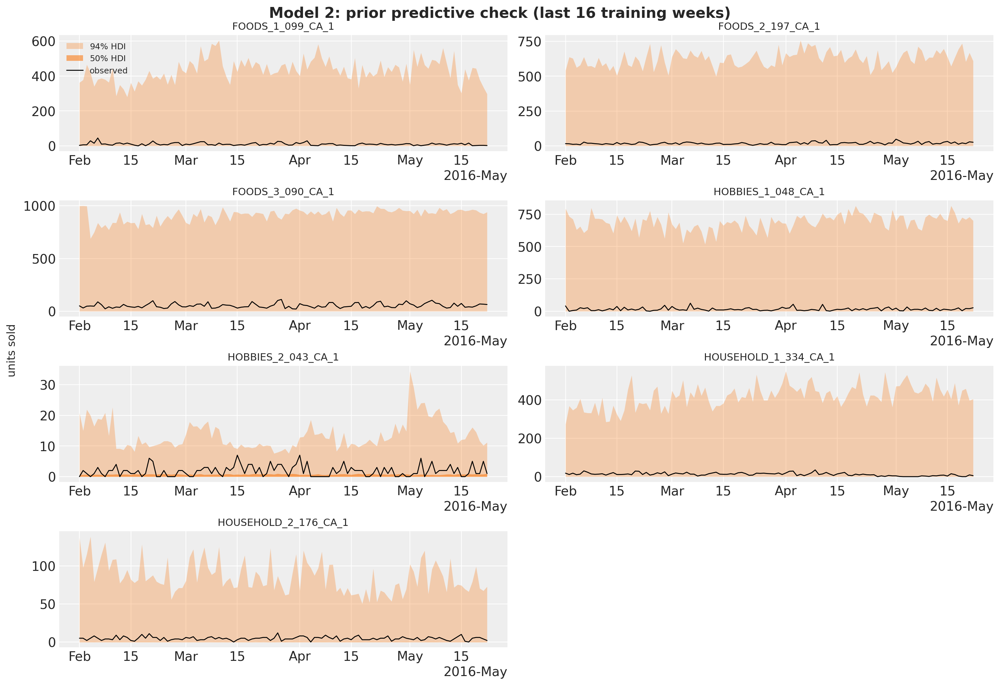

In [25]:
focus_model = make_bottom_up_model(store_index[focus_index], dept_index[focus_index])
covariates_focus = covariates_bottom[:, :, focus_index]

rng_key, key_prior = random.split(rng_key)
prior_obs_focus = Predictive(focus_model, num_samples=500, return_sites=["obs"])(
    key_prior, covariates_focus[:, plot_start:N_DAYS_TRAIN]
)["obs"]
plot_series_panel(
    None,
    prior_obs_focus,
    sales[plot_start:N_DAYS_TRAIN, focus_index],
    focus_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[plot_start:N_DAYS_TRAIN],
    ylabel="units sold",
    suptitle="Model 2: prior predictive check (last 16 training weeks)",
    group="prior_predictive",
)
del prior_obs_focus

### Fit

Each step evaluates the Gamma likelihood of 600 series over 1,820 days (about 1.1 million cells), so the 1,001 steps take about a minute despite the 55 million cells of the full panel. The loss is noisy because of the subsampling.

model 2: 1001 steps in 56.9 s, final loss -1.102e+08


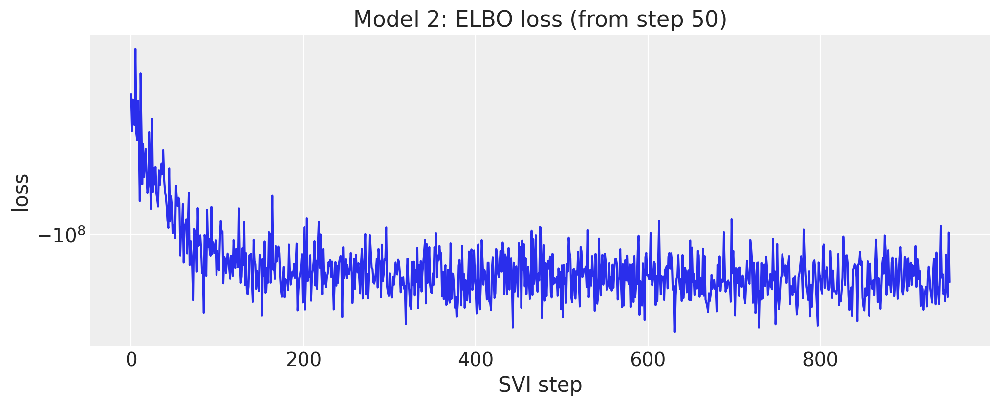

In [26]:
rng_key, key_fit = random.split(rng_key)
guide_bottom = AutoNormal(bottom_up_model, create_plates=create_series_plates)
svi_bottom, time_bottom = fit_svi(
    key_fit,
    bottom_up_model,
    guide_bottom,
    NUM_STEPS["bottom-up"],
    covariates_bottom_train,
    y_bottom_train,
)
print(
    f"model 2: {NUM_STEPS['bottom-up']} steps in {time_bottom:.1f} s, final loss {float(svi_bottom.losses[-1]):.4g}"
)
plot_loss(svi_bottom.losses[50:], "Model 2: ELBO loss (from step 50)")

### Posterior

The posterior has 1,540 parameters: for every store, the two heads times three moving averages times seven departments, the SNAP effect per head and department, and the weekday effects. We export the draws to ArviZ with named coordinates (the full posterior predictive of 30,490 series over 1,820 days would not fit in memory, so this tree carries the posterior only). The SNAP effect on the mean is a food effect: it is largest in the `FOODS_2` and `FOODS_3` departments, where a food-stamp day lifts the expected sales by 5% to 75% depending on the store, and within $\pm 0.1$ on the log scale for the hobbies and household departments.

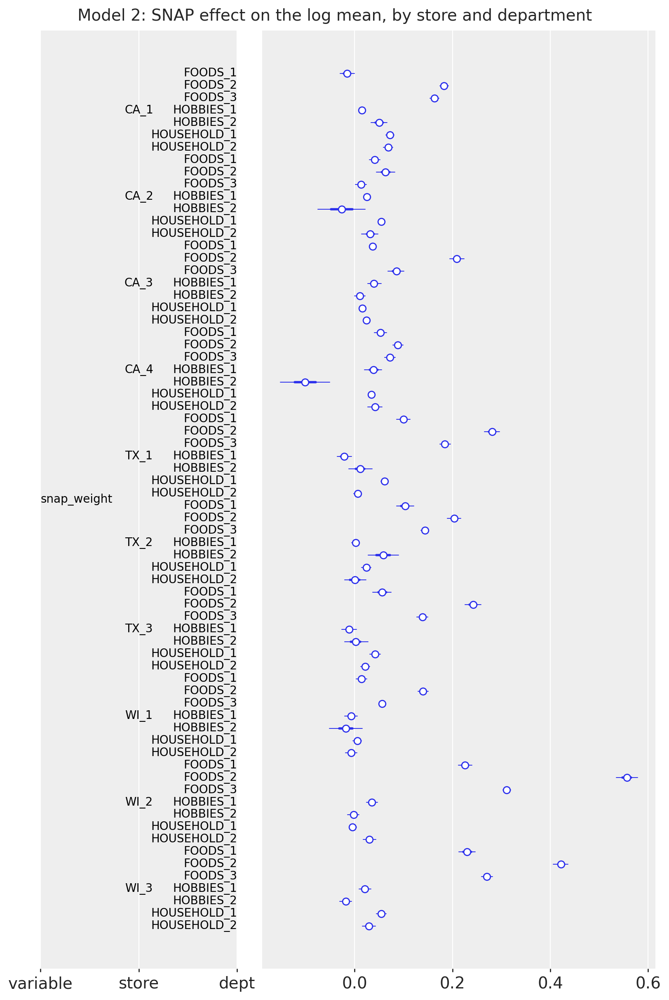

In [27]:
rng_key, key_post = random.split(rng_key)
posterior_bottom = draw_posterior(key_post, guide_bottom, svi_bottom.params, 500)
tree_bottom = az.from_dict(
    {"posterior": {name: np.asarray(value)[None] for name, value in posterior_bottom.items()}},
    coords={
        "store": store_ids,
        "dept": dept_ids,
        "head": ["mean", "scale"],
        "lag": ["MA 28", "MA 56", "MA 84"],
        "day_of_week": DOW_LABELS,
    },
    dims={
        "ma_weight": ["store", "head", "lag", "dept"],
        "snap_weight": ["store", "head", "dept"],
        "seasonal": ["store", "day_of_week", "head", "dept"],
    },
)
pc = az.plot_forest(
    tree_bottom,
    var_names=["snap_weight"],
    coords={"head": "mean"},
    combined=True,
    figure_kwargs={"figsize": (8, 12)},
)
pc.viz["figure"].item().suptitle(
    "Model 2: SNAP effect on the log mean, by store and department", fontsize=14
);

The moving-average weights of the mean head in store CA_1 show how the model reads an item's history. The three windows overlap (the 84-day window contains the other two), so the individual weights are weakly identified and change sign from one department to the next; in `HOBBIES_2` the 56-day and 84-day weights nearly cancel at about $\mp 1$. What is stable is their sum, between 0.25 and 0.4 in every department: an exponent below one on the recent level, which shrinks the high sellers toward their department.

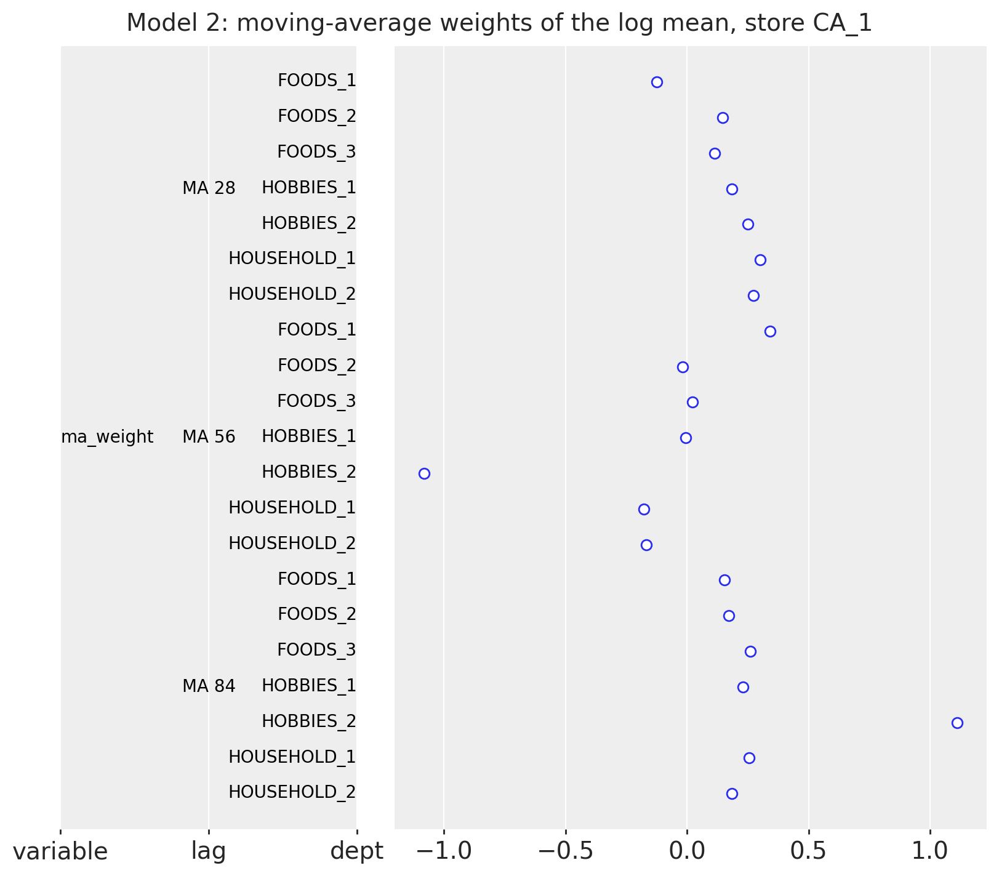

In [28]:
pc = az.plot_forest(
    tree_bottom,
    var_names=["ma_weight"],
    coords={"head": "mean", "store": "CA_1"},
    combined=True,
    figure_kwargs={"figsize": (8, 7)},
)
pc.viz["figure"].item().suptitle(
    "Model 2: moving-average weights of the log mean, store CA_1", fontsize=14
);

### Item forecasts

The posterior predictive of the focus items over the last sixteen training weeks and the evaluation window. The Gamma has its mode at zero whenever its shape $m / v$ is below one, so the $50\%$ HDI of an intermittent item sits on the floor while the $94\%$ band covers the spikes; for the food best sellers the bands follow the weekly pattern but the model, which has no item-level parameters, underestimates the level of the top seller `FOODS_3_090_CA_1`.

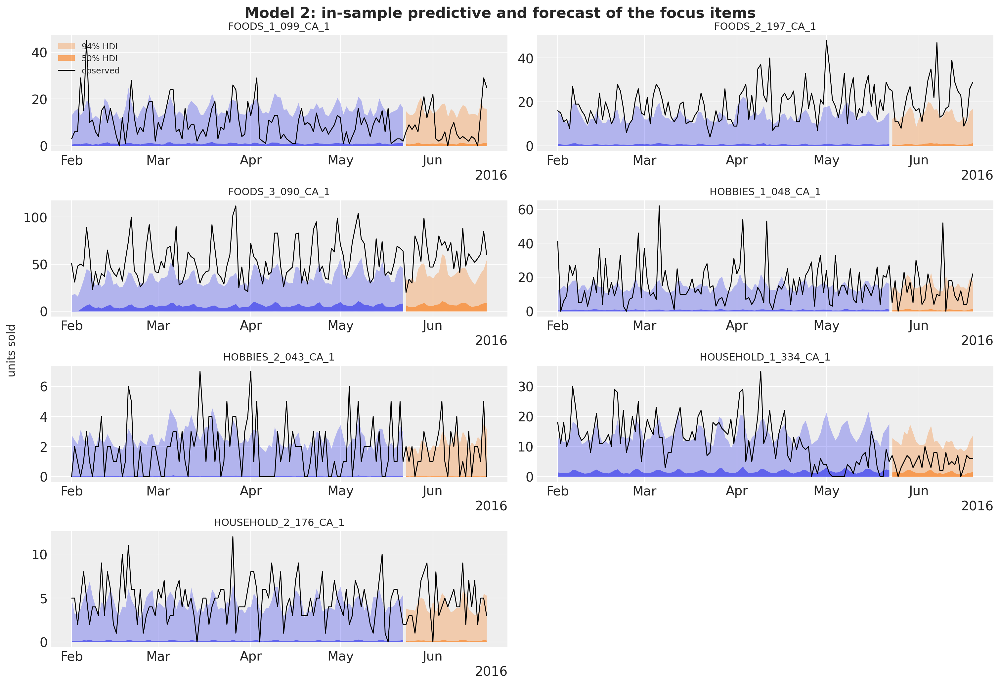

In [29]:
rng_key, key_pp, key_fc = random.split(rng_key, 3)
pp_focus = predict_in_sample(
    key_pp, focus_model, posterior_bottom, covariates_focus[:, plot_start:N_DAYS_TRAIN]
)
fc_focus = forecast(
    key_fc,
    focus_model,
    posterior_bottom,
    y_bottom[N_DAYS_TRAIN - TAIL : N_DAYS_TRAIN, focus_index],
    covariates_focus[:, N_DAYS_TRAIN - TAIL :],
)
plot_series_panel(
    pp_focus,
    fc_focus,
    sales[plot_start:N_DAYS, focus_index],
    focus_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Model 2: in-sample predictive and forecast of the focus items",
)
del pp_focus, fc_focus

### Bottom-up aggregation and scores

The forecast of all 30,490 series takes about two minutes: the Gamma sampler dominates (500 draws of 28 days for every series). As the kit does, only the last week of data is passed to `forecast()`, since the model needs no history beyond its covariates. The draws are summed to every level and scored.

In [30]:
rng_key, key_fc = random.split(rng_key)
start = perf_counter()
bottom_bottom = np.asarray(
    forecast(
        key_fc,
        bottom_up_model,
        posterior_bottom,
        y_bottom[N_DAYS_TRAIN - TAIL : N_DAYS_TRAIN],
        covariates_bottom[:, N_DAYS_TRAIN - TAIL :],
        batch_size=50,
        device="host",
    ),
    dtype=np.float32,
)
print(f"forecast of {bottom_bottom.shape} draws in {perf_counter() - start:.0f} s")
pred_levels, truth_levels = aggregate_transform(bottom_bottom, truth_holdout)
scores_holdout["bottom-up"] = evaluate_forecast(pred_levels, truth_levels, metrics=holdout_metrics)
wspl_holdout["bottom-up"] = ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)
level1_draws["bottom-up"] = pred_levels[..., level_slices["Level1"]]
level3_draws["bottom-up"] = pred_levels[..., level_slices["Level3"]]
del bottom_bottom, pred_levels
mean_ws_crps = np.mean(list(scores_holdout["bottom-up"].values()))
print(
    f"model 2 evaluation window: WS-CRPS {mean_ws_crps:.3f}, WSPL {wspl_holdout['bottom-up']:.3f}"
)

forecast of (500, 28, 30490) draws in 112 s


model 2 evaluation window: WS-CRPS 0.728, WSPL 0.266


Summed to the store level, the bottom-up forecast keeps the weekly pattern of every store, but the bands are narrow: the 3,049 Gamma draws of a store are independent given the parameters, so their sum has far less spread than the store's sales.

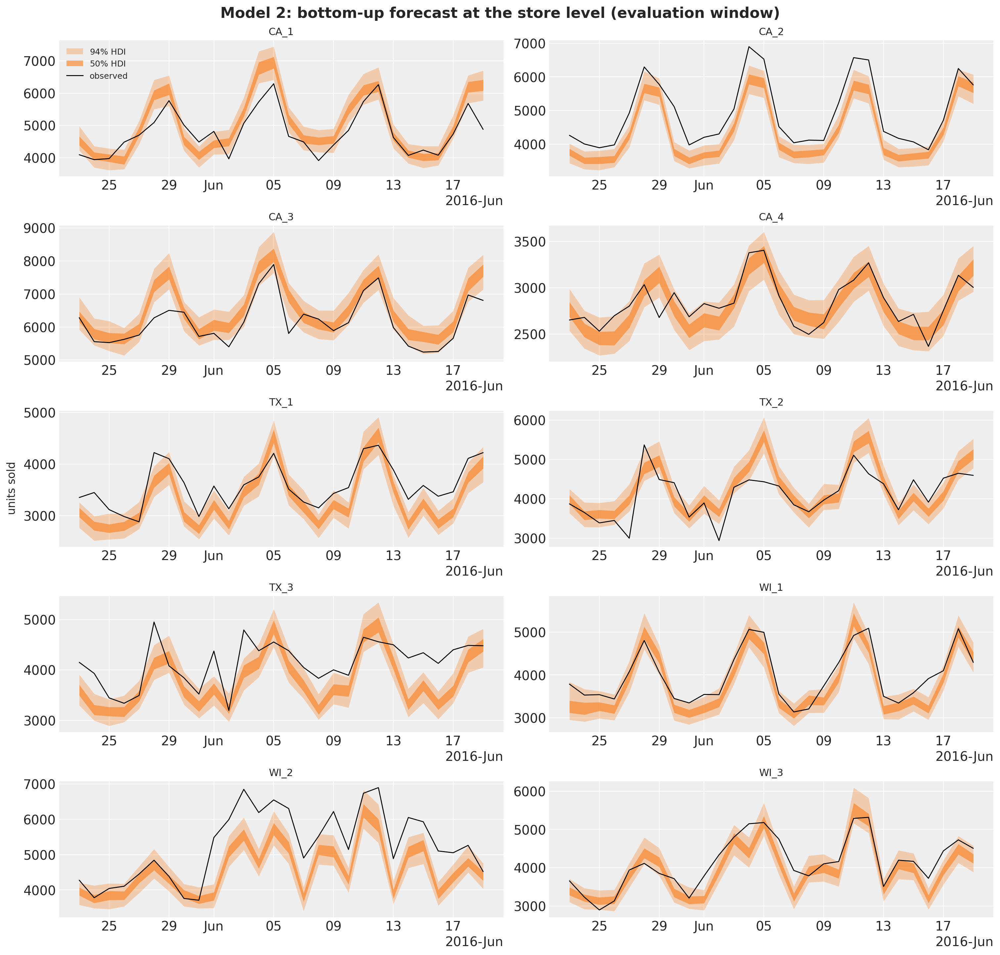

In [31]:
plot_series_panel(
    None,
    level3_draws["bottom-up"],
    sales_agg[N_DAYS_TRAIN:N_DAYS, level_slices["Level3"]],
    store_ids,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Model 2: bottom-up forecast at the store level (evaluation window)",
    figsize=(15.0, 14.0),
)

## Model 3: middle-out

### Model specification

Model 3 works on the 70 store-by-department series (level 9). Each series $j$ is divided by its scale $\sigma_j$, the mean absolute lag-one difference over the training window (the scale of the competition metric, so $y_{j,t} = \text{sales}_{j,t} / \sigma_j$ is in units of a typical daily change). With $\mathbf{f}_t$ the 104 Fourier terms of a yearly cycle (52 harmonics, down to a period of one week),

$$
\begin{align*}
\mu_{j,t} &= \beta_{0,j} + \beta_{\text{trend},j}\, \tau_t + s_{j, d(t)} + \mathbf{w}_j^\top \mathbf{f}_t, \\
y_{j,t} &\sim \text{StudentT}(\nu, \mu_{j,t}, \sigma_{\text{noise},j}),
\end{align*}
$$

with $\beta_{0,j} \sim \text{Normal}(0, 10)$, $\beta_{\text{trend},j} \sim \text{LogNormal}(-1, 1)$, $s_{j,d} \sim \text{Normal}(0, 1)$, $w_{j,k} \sim \text{Normal}(0, 1)$, $\sigma_{\text{noise},j} \sim \text{LogNormal}(-1, 1)$ and one shared $\nu \sim \text{Uniform}(1, 10)$. The series are independent given $\nu$: this is a batch of 70 univariate regressions, written with a `series` plate on the observation axis and a `day_of_week` plate for the weekday effects.

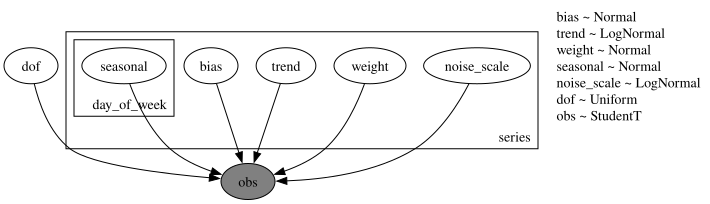

In [32]:
covariates_mid = jnp.asarray(
    np.column_stack(
        [
            calendar_df["years"].to_numpy()[:N_DAYS],
            calendar_df["dow"].to_numpy()[:N_DAYS],
            np.asarray(fourier_features(N_DAYS, 365.25, 52)),
        ]
    ).astype(np.float32)
)
covariates_mid_train = covariates_mid[:N_DAYS_TRAIN]
N_MID = len(level9_labels)
scale_mid = m5_scales(y_level9[:N_DAYS_TRAIN])
y_mid = jnp.asarray(y_level9 / scale_mid, dtype=jnp.float32)
y_mid_train = y_mid[:N_DAYS_TRAIN]


def middle_out_model(covariates: Array, data: Array | None = None) -> None:
    """Kit model 3: per-series trend, weekly and yearly seasonality on scaled level-9 sales."""
    h = Horizon.from_data(covariates, data)
    time = covariates[:, :1]
    dow = covariates[:, 1].astype(jnp.int32)
    feature = covariates[:, 2:]
    with numpyro.plate("series", N_MID):
        bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
        trend = numpyro.sample("trend", dist.LogNormal(-1.0, 1.0))
        weight = numpyro.sample(
            "weight", dist.Normal(0.0, 1.0).expand([feature.shape[-1]]).to_event(1)
        )
        with numpyro.plate("day_of_week", 7, dim=-2):
            seasonal = numpyro.sample("seasonal", dist.Normal(0.0, 1.0))
        noise_scale = numpyro.sample("noise_scale", dist.LogNormal(-1.0, 1.0))
    dof = numpyro.sample("dof", dist.Uniform(1.0, 10.0))
    prediction = bias + trend * time + seasonal[dow] + feature @ weight.T
    predict(h, dist.StudentT(dof, 0.0, noise_scale), prediction)


numpyro.render_model(
    middle_out_model, model_args=(covariates_mid_train, y_mid_train), render_distributions=True
)

### Prior predictive check

On the scaled axis a store-department sells a few typical daily changes a day: the medians of the 70 training series lie between 2 and 8, and those of the seven departments of store CA_1 between 2 and 6. The prior intercept with a standard deviation of 10 and the 104 Fourier weights with unit variance give $94\%$ prior bands of about $\pm 25$ and $50\%$ bands of about $\pm 10$ around a center a little above zero (the positive trend prior over five years): wide, but the data sit inside the $50\%$ band.

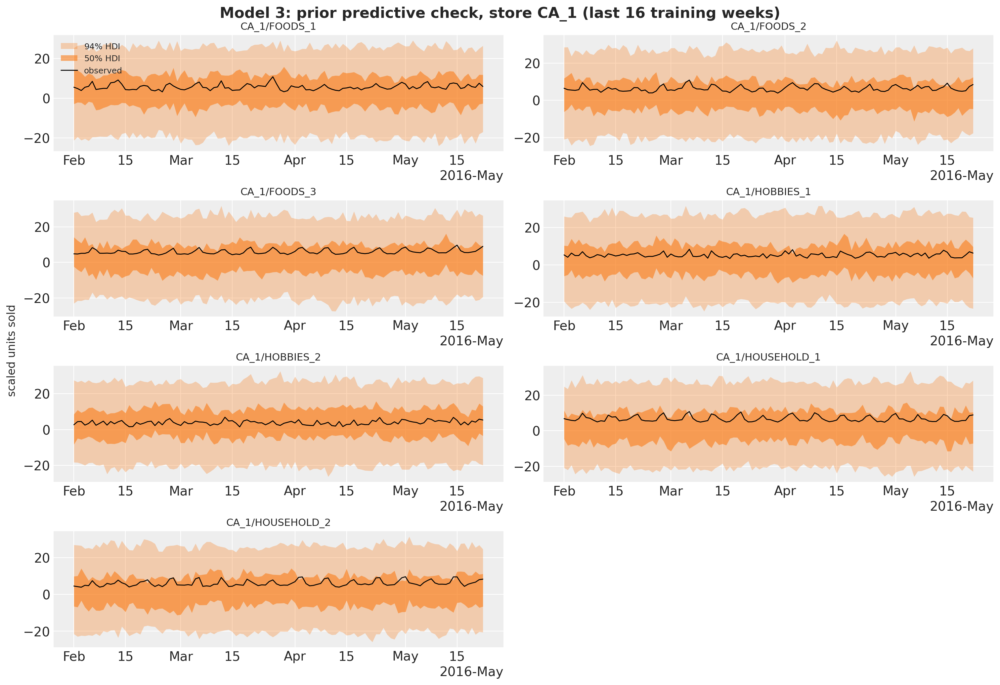

In [33]:
rng_key, key_prior = random.split(rng_key)
prior_obs_mid = Predictive(middle_out_model, num_samples=500, return_sites=["obs"])(
    key_prior, covariates_mid_train[plot_start:]
)["obs"]
ca1_labels = [level9_labels[k] for k in ca1_columns]
plot_series_panel(
    None,
    prior_obs_mid[:, :, ca1_columns],
    np.asarray(y_mid_train[plot_start:, ca1_columns]),
    ca1_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[plot_start:N_DAYS_TRAIN],
    ylabel="scaled units sold",
    suptitle="Model 3: prior predictive check, store CA_1 (last 16 training weeks)",
    group="prior_predictive",
)
del prior_obs_mid

### Fit

model 3: 2001 steps in 5.1 s, final loss 219410.7


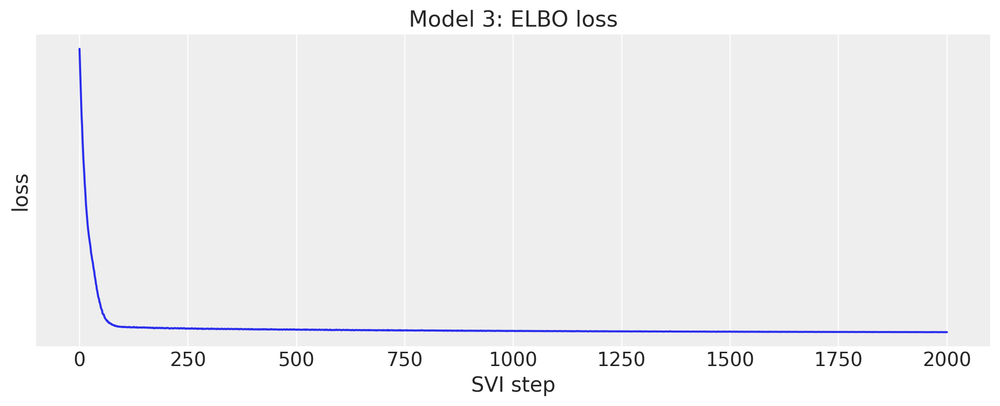

In [34]:
rng_key, key_fit = random.split(rng_key)
guide_mid = AutoNormal(middle_out_model)
svi_mid, time_mid = fit_svi(
    key_fit,
    middle_out_model,
    guide_mid,
    NUM_STEPS["middle-out"],
    covariates_mid_train,
    y_mid_train,
)
print(
    f"model 3: {NUM_STEPS['middle-out']} steps in {time_mid:.1f} s, final loss {float(svi_mid.losses[-1]):.1f}"
)
plot_loss(svi_mid.losses, "Model 3: ELBO loss")

### Posterior

The degrees of freedom are shared by the 70 series, about 6.5. The trends are per series: in store CA_1 they range from 0.14 (`FOODS_2`) to 0.88 (`HOUSEHOLD_1`) typical daily changes per year. The noise scales are the residual spread in units of a typical daily change, between 0.55 and 0.9.

In [35]:
rng_key, key_post, key_tree = random.split(rng_key, 3)
posterior_mid = draw_posterior(key_post, guide_mid, svi_mid.params, 500)
tree_mid = to_datatree(
    key_tree,
    middle_out_model,
    posterior_mid,
    y_mid_train,
    covariates_mid,
    coords={"series": level9_labels, "obs_dim": level9_labels, "day_of_week": DOW_LABELS},
    posterior_dims={
        "bias": ["series"],
        "trend": ["series"],
        "noise_scale": ["series"],
        "seasonal": ["day_of_week", "series"],
        "weight": ["series", "fourier"],
    },
)
az.summary(tree_mid, var_names=["dof"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
dof,6.465,0.084,6.3,6.6,443,423,nan,0.004,0.0028


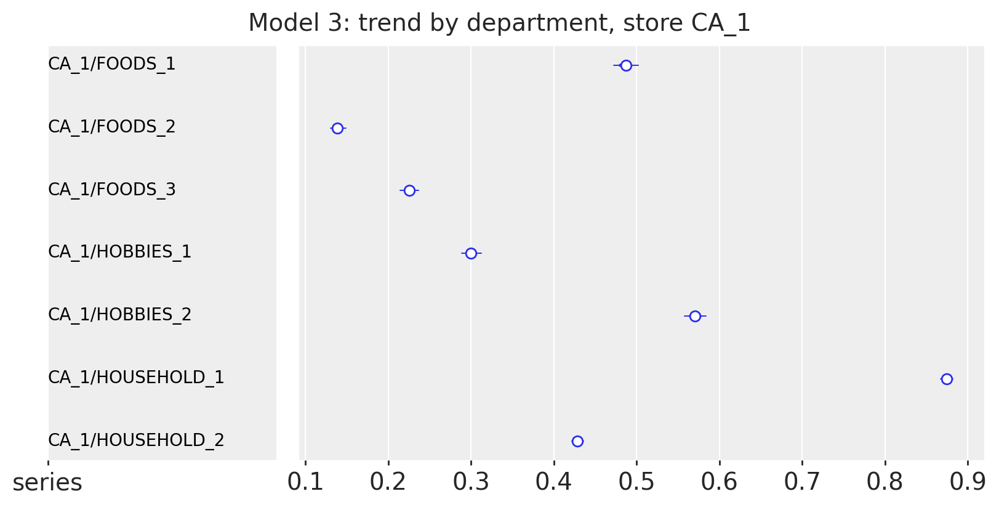

In [36]:
pc = az.plot_forest(
    tree_mid,
    var_names=["trend"],
    coords={"series": ca1_labels},
    combined=True,
    labels=["series"],
    figure_kwargs={"figsize": (8, 4)},
)
pc.viz["figure"].item().suptitle("Model 3: trend by department, store CA_1", fontsize=14);

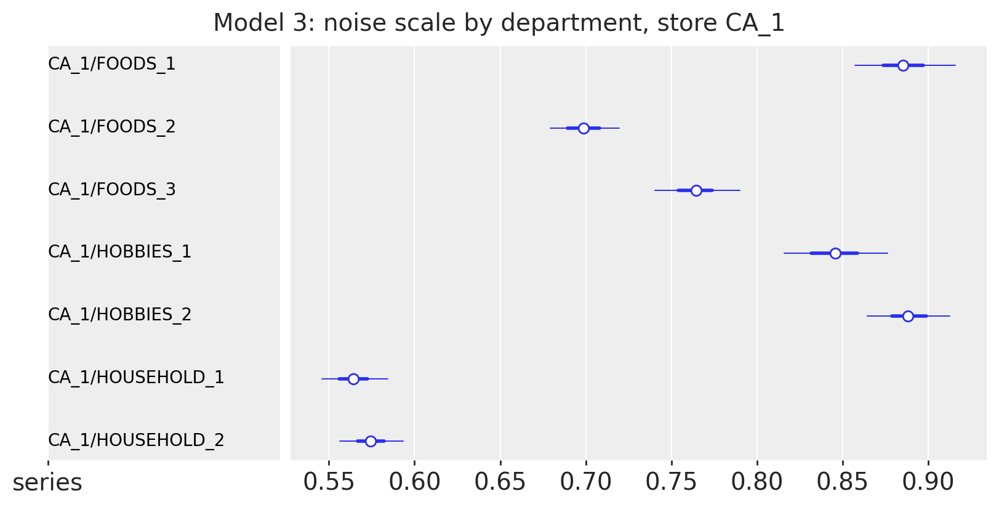

In [37]:
pc = az.plot_forest(
    tree_mid,
    var_names=["noise_scale"],
    coords={"series": ca1_labels},
    combined=True,
    labels=["series"],
    figure_kwargs={"figsize": (8, 4)},
)
pc.viz["figure"].item().suptitle("Model 3: noise scale by department, store CA_1", fontsize=14);

### Store-department forecasts

The in-sample predictive over the last sixteen training weeks and the forecast for the seven departments of store CA_1, back in units.

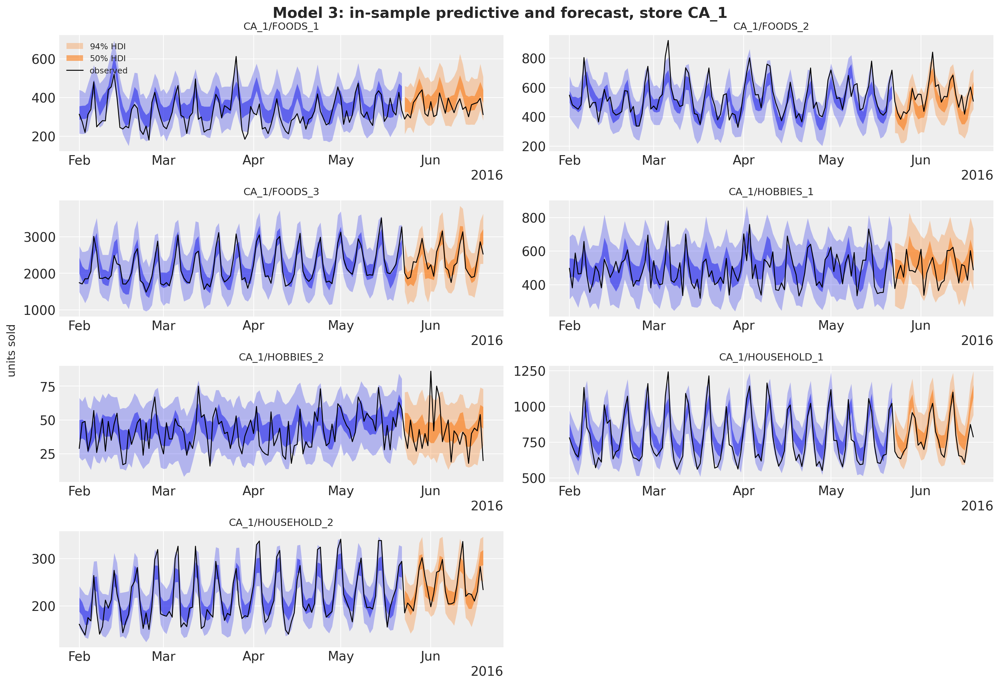

In [38]:
rng_key, key_pp, key_fc = random.split(rng_key, 3)
pp_mid = predict_in_sample(
    key_pp, middle_out_model, posterior_mid, covariates_mid_train[plot_start:]
)
fc_mid = np.asarray(forecast(key_fc, middle_out_model, posterior_mid, y_mid_train, covariates_mid))
plot_series_panel(
    np.asarray(pp_mid)[:, :, ca1_columns] * scale_mid[ca1_columns],
    fc_mid[:, :, ca1_columns] * scale_mid[ca1_columns],
    y_level9[plot_start:N_DAYS, ca1_columns],
    ca1_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Model 3: in-sample predictive and forecast, store CA_1",
)
del pp_mid

### Middle-out split and scores

The forecast draws go back to units (clipped at zero: a StudentT can go negative), are split to the items of each store-department with their last-28-day shares, get Poisson noise, and are summed up to the levels above.

In [39]:
shares_mid = last_28_day_shares(sales[:N_DAYS_TRAIN], level9_index)
bottom_mid = disaggregate(
    N_DAYS_TRAIN, np.clip(fc_mid, 0.0, None) * scale_mid, shares_mid, level9_index
)
pred_levels, truth_levels = aggregate_transform(bottom_mid, truth_holdout)
scores_holdout["middle-out"] = evaluate_forecast(
    pred_levels, truth_levels, metrics=holdout_metrics
)
wspl_holdout["middle-out"] = ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)
level1_draws["middle-out"] = pred_levels[..., level_slices["Level1"]]
level3_draws["middle-out"] = pred_levels[..., level_slices["Level3"]]
del bottom_mid, pred_levels
mean_ws_crps = np.mean(list(scores_holdout["middle-out"].values()))
print(
    f"model 3 evaluation window: WS-CRPS {mean_ws_crps:.3f}, WSPL {wspl_holdout['middle-out']:.3f}"
)

model 3 evaluation window: WS-CRPS 0.634, WSPL 0.222


## Backtesting

The kit backtests on three windows of 28 days inside the training period, 35 days apart (origins at days 1,843, 1,878 and 1,913), refitting on all the data before each origin. `backtest()` does the same with `min_train_window` and `stride`. It takes the raw bottom-level sales as `data` for all three models, and each `forecast_fn` closure builds its own training target from the window (the log of the total, the scaled level-9 sums, or the clamped counts from day 121), fits, forecasts and returns bottom-level draws, so the same `transform` and `per_window_metrics` score the three models. The windows use 250 draws to keep the run time of model 2 at about six minutes.

In [40]:
def forecast_fn_top(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """Fit the top-down model on the log of the total and split its forecast to the bottom."""
    key_fit, key_post, key_fc = random.split(rng_key, 3)
    y = jnp.log(train_data.sum(-1, keepdims=True))
    guide = AutoNormal(model)
    result, _ = fit_svi(key_fit, model, guide, NUM_STEPS["top-down"], train_covariates, y)
    posterior = draw_posterior(key_post, guide, result.params, num_samples)
    draws = np.exp(np.asarray(forecast(key_fc, model, posterior, y, full_covariates)))
    shares = last_28_day_shares(np.asarray(train_data[-28:]), total_index)
    return disaggregate(int(train_data.shape[0]), draws, shares, total_index)


level9_matrix = agg_matrix[:, level_slices["Level9"]]


def forecast_fn_mid(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """Fit the middle-out model on scaled level-9 sales and split its forecast to the bottom."""
    key_fit, key_post, key_fc = random.split(rng_key, 3)
    y_raw = np.asarray(train_data) @ level9_matrix
    scale = m5_scales(y_raw)
    y = jnp.asarray(y_raw / scale, dtype=jnp.float32)
    guide = AutoNormal(model)
    result, _ = fit_svi(key_fit, model, guide, NUM_STEPS["middle-out"], train_covariates, y)
    posterior = draw_posterior(key_post, guide, result.params, num_samples)
    draws = np.asarray(forecast(key_fc, model, posterior, y, full_covariates))
    shares = last_28_day_shares(np.asarray(train_data[-28:]), level9_index)
    return disaggregate(
        int(train_data.shape[0]), np.clip(draws, 0.0, None) * scale, shares, level9_index
    )


def forecast_fn_bottom(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """Fit the bottom-up model with subsampled SVI and forecast every series from its last week."""
    key_fit, key_post, key_fc = random.split(rng_key, 3)
    t1 = train_data.shape[0]
    y = jnp.maximum(train_data[T0:], 1e-3)
    guide = AutoNormal(model, create_plates=create_series_plates)
    result, _ = fit_svi(key_fit, model, guide, NUM_STEPS["bottom-up"], train_covariates[:, T0:], y)
    posterior = draw_posterior(key_post, guide, result.params, num_samples)
    draws = forecast(
        key_fc,
        model,
        posterior,
        y[-TAIL:],
        full_covariates[:, t1 - TAIL :],
        batch_size=50,
        device="host",
    )
    return np.asarray(draws, dtype=np.float32)


BACKTEST_OPTIONS = {
    "test_window": HORIZON,
    "stride": 35,
    "min_train_window": N_DAYS_TRAIN - HORIZON - 2 * 35,
    "num_samples": 250,
    "transform": aggregate_transform,
    "per_window_metrics": m5_metrics,
}
sales_train = jnp.asarray(sales[:N_DAYS_TRAIN])
backtest_runs = {
    "top-down": (top_down_model, covariates_top_train, forecast_fn_top),
    "bottom-up": (bottom_up_model, covariates_bottom[:, :N_DAYS_TRAIN], forecast_fn_bottom),
    "middle-out": (middle_out_model, covariates_mid_train, forecast_fn_mid),
}
backtest_results = {}
for name, (model, covariates, forecast_fn) in backtest_runs.items():
    rng_key, key_bt = random.split(rng_key)
    start = perf_counter()
    backtest_results[name] = backtest(
        key_bt,
        lambda model=model: model,
        sales_train,
        covariates,
        forecast_fn=forecast_fn,
        **BACKTEST_OPTIONS,
    )
    print(f"{name}: {len(backtest_results[name])} windows in {perf_counter() - start:.0f} s")

top-down: 3 windows in 56 s


bottom-up: 3 windows in 356 s


middle-out: 3 windows in 61 s


`results_to_dataframe` turns the results into one row per window with a column per metric. The headline WS-CRPS is the mean over the 12 level columns, and `walltime` is the time of the whole `forecast_fn` (fit, draws, forecast and reconciliation).

In [41]:
level_columns = [f"metric_ws_crps_{level}" for level in LEVELS]
backtest_df = pl.concat(
    [
        pl.from_pandas(results_to_dataframe(results))
        .with_columns(model=pl.lit(name), ws_crps=pl.mean_horizontal(level_columns))
        .select("model", "t1", "t2", "walltime", "ws_crps", *level_columns)
        for name, results in backtest_results.items()
    ]
)
backtest_df.select("model", "t1", "t2", "walltime", "ws_crps").with_columns(
    pl.col("walltime").round(1), pl.col("ws_crps").round(3)
)

model,t1,t2,walltime,ws_crps
"""top-down""",1843,1871,9.1,0.557
"""top-down""",1878,1906,8.9,0.553
"""top-down""",1913,1941,9.0,0.581
"""bottom-up""",1843,1871,110.5,0.802
"""bottom-up""",1878,1906,100.8,0.719
"""bottom-up""",1913,1941,103.8,0.763
"""middle-out""",1843,1871,11.5,0.622
"""middle-out""",1878,1906,11.0,0.676
"""middle-out""",1913,1941,10.8,0.746


The ranking is the same in every window: the top-down model scores best, the middle-out model second and the bottom-up model last. The top-down score is stable (0.55 to 0.58), the middle-out score degrades from window to window (0.62 to 0.75) and the bottom-up score is the noisiest (0.72 to 0.80). The last window (origin at day 1,913, the four weeks before Memorial Day) is the hardest for the two split models, and the evaluation window is right after it.

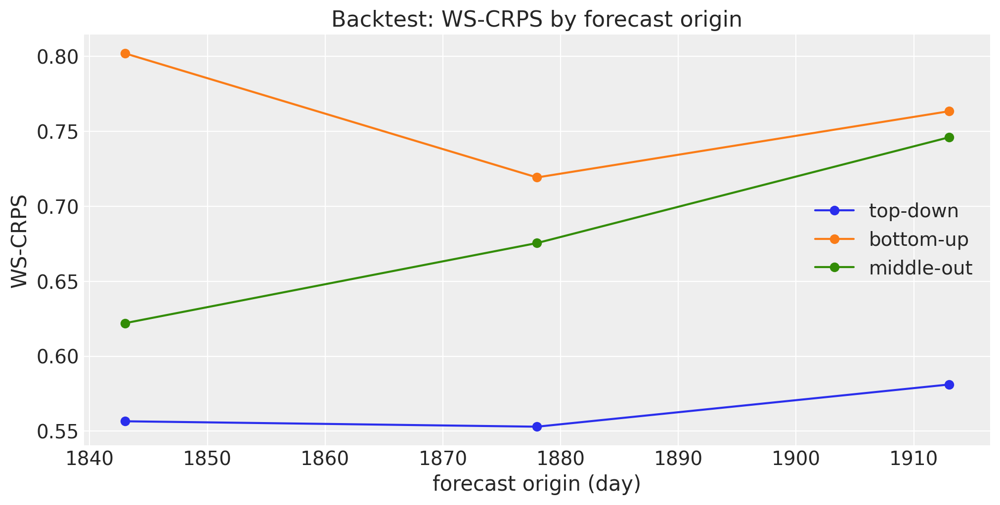

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
for name in backtest_runs:
    rows = backtest_df.filter(pl.col("model").eq(pl.lit(name))).sort("t1")
    ax.plot(rows["t1"], rows["ws_crps"], marker="o", label=name)
ax.set(
    title="Backtest: WS-CRPS by forecast origin", xlabel="forecast origin (day)", ylabel="WS-CRPS"
)
ax.legend();

Averaged over the three windows, the per-level scores show where each strategy pays. The top-down model is best at every level from the total to the store-departments (levels 1 to 9). At the item levels (10 to 12) the top-down and middle-out models are indistinguishable, because both hand the same share split the same Poisson noise, and the bottom-up model is far behind: it has to get every intermittent series right on its own, while the split turns a good aggregate into a serviceable item forecast.

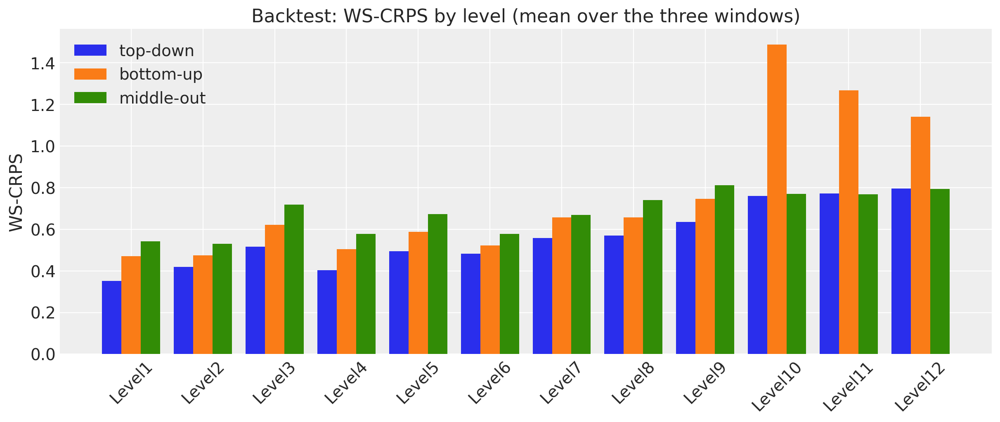

In [43]:
backtest_levels = pl.DataFrame(
    {"level": list(LEVELS)}
    | {
        name: backtest_df.filter(pl.col("model").eq(pl.lit(name)))
        .select(level_columns)
        .mean()
        .row(0)
        for name in backtest_runs
    }
)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(LEVELS))
width = 0.27
for k, name in enumerate(backtest_runs):
    ax.bar(x + (k - 1) * width, backtest_levels[name].to_numpy(), width, label=name)
ax.set_xticks(x, list(LEVELS), rotation=45)
ax.set(title="Backtest: WS-CRPS by level (mean over the three windows)", ylabel="WS-CRPS")
ax.legend();

## Evaluation window

The final fits of the three sections forecast the official evaluation window (days 1,942 to 1,969, released after the competition). The per-level WS-CRPS table below repeats the backtest ranking: the top-down model is best at every level except the state level, where the middle-out model is ahead by 0.005. The WSPL row is the competition metric with the official weights: the winner of the uncertainty competition scored 0.154 and the runner-up 0.159 (Makridakis et al., 2022), so the kit's models are baselines, not contenders, but the table shows what the three reconciliation strategies do with the same data.

In [44]:
holdout_table = ws_crps_table(scores_holdout)
holdout_table = pl.concat(
    [
        holdout_table,
        pl.DataFrame(
            {"level": ["WSPL"]} | {name: [round(value, 3)] for name, value in wspl_holdout.items()}
        ),
    ]
)
holdout_table

level,top-down,bottom-up,middle-out
"""Level1""",0.294,0.37,0.3
"""Level2""",0.39,0.438,0.385
"""Level3""",0.495,0.587,0.762
"""Level4""",0.343,0.416,0.355
"""Level5""",0.462,0.559,0.498
"""Level6""",0.457,0.48,0.459
"""Level7""",0.547,0.603,0.583
"""Level8""",0.55,0.605,0.766
"""Level9""",0.625,0.7,0.816
"""Level10""",0.922,1.566,0.934


At the top level the three forecasts are close to the observed total and differ mostly in their spread: the top-down model's StudentT gives the widest bands, the bottom-up sum of independent Gamma draws the narrowest.

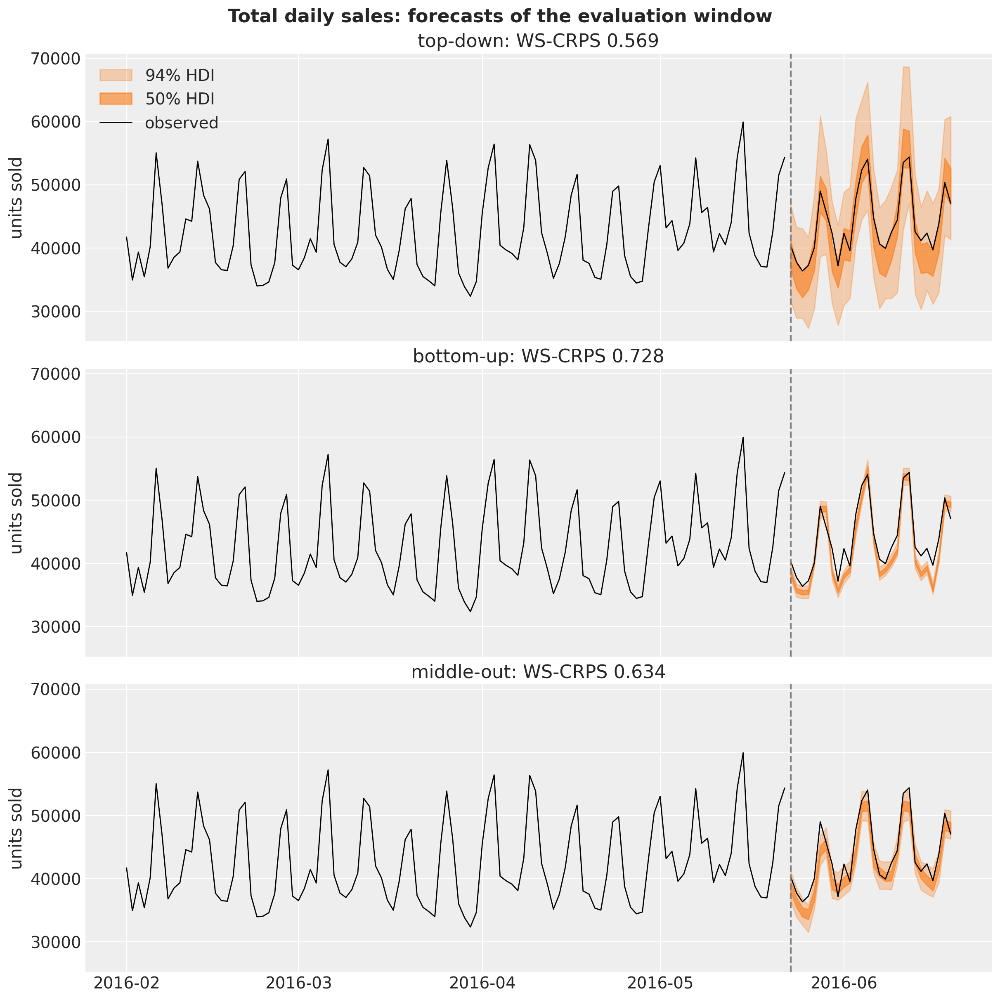

In [45]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, sharey=True, layout="constrained"
)
x_hist = date_num[plot_start:N_DAYS_TRAIN]
x_test = date_num[N_DAYS_TRAIN:N_DAYS]
for ax, (name, draws) in zip(axes, level1_draws.items(), strict=True):
    total_draws = draws[..., 0]
    for prob, alpha in zip(HDI_PROBS, HDI_ALPHAS, strict=True):
        hdi = az.hdi(total_draws.T, prob=prob)
        ax.fill_between(
            x_test, hdi[:, 0], hdi[:, 1], color="C1", alpha=alpha, label=hdi_label(prob)
        )
    ax.plot(x_hist, y_total[plot_start:N_DAYS_TRAIN], color="black", lw=1, label="observed")
    ax.plot(x_test, y_total[N_DAYS_TRAIN:N_DAYS], color="black", lw=1)
    ax.axvline(split_date, color="gray", ls="--")
    ax.set(
        title=f"{name}: WS-CRPS {np.mean(list(scores_holdout[name].values())):.3f}",
        ylabel="units sold",
    )
axes[0].legend(loc="upper left")
axes[-1].xaxis_date()
fig.suptitle(
    "Total daily sales: forecasts of the evaluation window", fontsize=16, fontweight="bold"
);

## Fitting times

The wall times of the three final fits, JIT compilation included. Model 2 evaluates 1.1 million Gamma densities per step and gathers its minibatch from a 1.4 GB covariate tensor; model 3 runs twice the steps of the others on 70 series with 104 features; model 1 is a single series. Per step, model 2 costs more than ten times model 1 (the exact ratio moves with the JIT compilation share of these short fits).

model,steps,fit_seconds,ms_per_step
"""top-down""",1001,4.1,4.1
"""bottom-up""",1001,56.9,56.9
"""middle-out""",2001,5.1,2.6


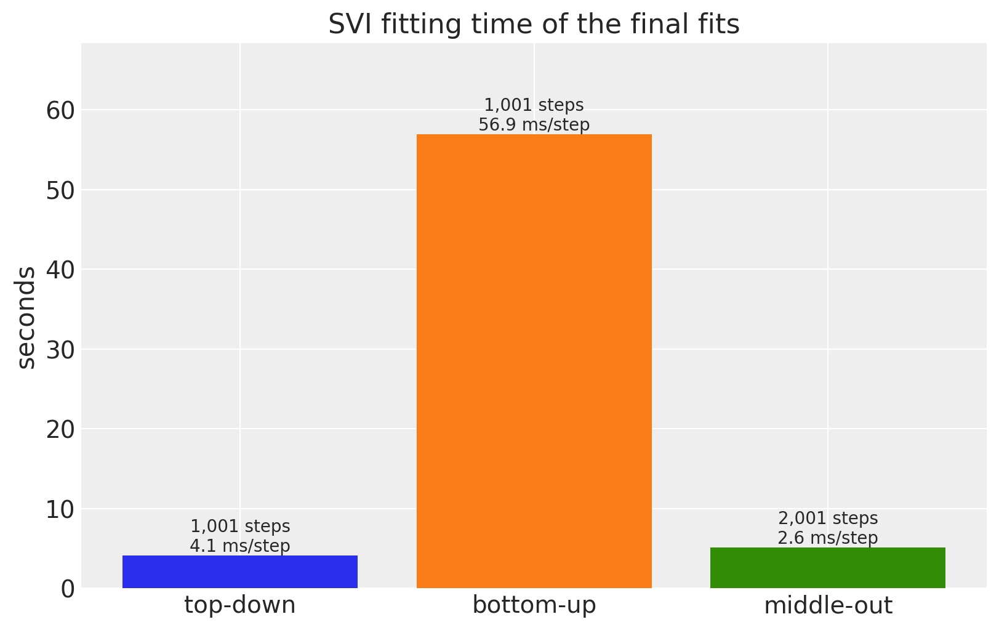

In [46]:
fit_times = pl.DataFrame(
    {
        "model": list(NUM_STEPS),
        "steps": list(NUM_STEPS.values()),
        "fit_seconds": [time_top, time_bottom, time_mid],
    }
).with_columns(ms_per_step=pl.col("fit_seconds").truediv(pl.col("steps")).mul(pl.lit(1_000.0)))
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(fit_times["model"], fit_times["fit_seconds"], color=["C0", "C1", "C2"])
for bar, steps, ms in zip(bars, fit_times["steps"], fit_times["ms_per_step"], strict=True):
    ax.annotate(
        f"{steps:,} steps\n{ms:.1f} ms/step",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set(title="SVI fitting time of the final fits", ylabel="seconds")
ax.margins(y=0.2)
fit_times.with_columns(pl.col("fit_seconds").round(1), pl.col("ms_per_step").round(1))

## Discussion

- **Top-down has the best mean score in this port**, on the evaluation window and on the three backtest windows. Its total-level model has the fewest parameters, uses the most data per parameter, and its StudentT noise gives calibrated bands at the top; the share split carries that quality down as long as the item shares are stable over four weeks.
- **Middle-out is close behind at the total, state and category levels** and loses ground at the store levels (3, 8, 9): the 70 independent regressions cannot borrow strength across stores, and 104 Fourier weights per series with unit-variance priors fit the training years better than the next month.
- **Bottom-up is last**, as the kit's authors note in `model2.py`. Its Gamma likelihood on clamped counts puts the mode at zero for most items, it has no item-level parameters, and the sum of independent draws underestimates the uncertainty of every aggregate. The department-level weights are still interpretable (the SNAP effect is a food effect).
- **Item levels 10 to 12 of models 1 and 3 are not model forecasts**: they are the share heuristic with Poisson noise, which is exactly what the kit submits. That the heuristic beats the bottom-up model there says more about model 2 than about the split.
- The four evaluation windows all lie between February and June 2016; the ranking is consistent across them, but the differences are not tested for significance.

## Next steps

- Give model 2 a count likelihood (`NegativeBinomial2` is pre-registered for `predict()`) and an item-level intercept, and compare the aggregated bands again.
- Add a random-walk level to models 1 and 3 with `innovations()` and `time_reparam()` (the [univariate example](forecasting_univariate.html) shows the pattern), which the kit's Forecasting tutorials use for the same data.
- Reconcile the three forecasts with MinT-style weights instead of picking one strategy.

## References

- Pyro. [*Pyro M5 Starter Kit*](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit) (`model1.py`, `model2.py`, `model3.py`, `evaluate.py`).
- Pyro. [*Forecasting III: hierarchical models*](https://pyro.ai/examples/forecasting_iii.html).
- Makridakis, S., Spiliotis, E., Assimakopoulos, V., Chen, Z., Gaba, A., Tsetlin, I., Winkler, R. L. (2022). [*The M5 uncertainty competition: Results, findings and conclusions*](https://doi.org/10.1016/j.ijforecast.2021.10.009). International Journal of Forecasting, 38(4).
- Makridakis, S., Spiliotis, E., Assimakopoulos, V. (2022). [*The M5 competition: Background, organization, and implementation*](https://doi.org/10.1016/j.ijforecast.2021.07.007). International Journal of Forecasting, 38(4).
- Hyndman, R. J., Athanasopoulos, G. (2021). [*Forecasting: Principles and Practice*](https://otexts.com/fpp3/hierarchical.html), chapter 11 (hierarchical and grouped time series).
- Nixtla. [*m5-forecasts*](https://github.com/Nixtla/m5-forecasts) (the data mirror).
- Related examples: [hierarchical forecasting I](hierarchical_forecasting_1.html), [forecasting retail demand under stockouts](fresh_retail_stockout.html), [univariate forecasting](forecasting_univariate.html).